# Lección 4.3 · Modelos ocultos de Márkov (HMM) y perfiles: de las islas CpG a Pfam/HMMER

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juvenalyosa/bioinformatica-practica/blob/main/modulo-04-msa-motivos-hmm/4.3_modelos_ocultos_markov.ipynb) [![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai) [![Licencia: MIT](https://img.shields.io/badge/Licencia-MIT-2a78d6.svg)](https://github.com/juvenalyosa/bioinformatica-practica/blob/main/LICENSE)

**Módulo 4 — Alineamiento múltiple, motivos y perfiles** · Bioinformática Práctica (Maestría)

👤 **Juvenal Yosa, PhD** · ✉️ [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · 🤖 Copiloto: **Claude** (Anthropic)

| ⏱️ Duración | 📶 Nivel | 🧰 Requisitos |
|---|---|---|
| ~3.5 horas | Intermedio–avanzado | Lecciones 3.2 (programación dinámica), 3.4 (E-values) y 4.1–4.2 (alineamiento múltiple, motivos) |

---

## 🎯 Objetivos de aprendizaje

Al terminar esta clase usted podrá:

1. **Calcular** a mano la probabilidad de una secuencia de ADN bajo una **cadena de Márkov** y **estimar** su matriz de
   transición contando pares de bases.
2. **Explicar** qué es un **modelo oculto de Márkov** (HMM): estados ocultos, probabilidades de transición y de
   emisión, y **dibujar** su diagrama de estados.
3. **Resolver** a mano y **programar** el algoritmo de **Viterbi** (el camino de estados más probable) en espacio
   logarítmico.
4. **Programar** los algoritmos **Forward** y **Backward** y **usar** la probabilidad **posterior** de cada estado para
   medir la confianza de cada predicción.
5. **Entrenar** un HMM contando (cuando conocemos los estados) y con **Baum-Welch** (cuando no los conocemos).
6. **Detectar islas CpG** en 300 kb reales del cromosoma 17 humano (la región del gen *TP53*) y **validar** la
   predicción contra la anotación de UCSC.
7. **Construir** un **HMM de perfil** (estados Match, Insert y Delete) a partir de un alineamiento múltiple y
   **relacionarlo** con las familias de **Pfam**.
8. **Ejecutar** HMMER (`hmmbuild`, `hmmsearch`) en Colab para encontrar todos los transportadores ABC del proteoma de
   *Mycoplasma genitalium*.

## 🗺️ Mapa de la clase

1. Cadenas de Márkov: cuando la base siguiente depende de la anterior
2. Lo que no se ve: el casino deshonesto como HMM
3. El algoritmo de Viterbi: el camino más probable
4. 🎬 Animación: la trellis de Viterbi se llena
5. Forward, Backward y la probabilidad posterior
6. Entrenar un HMM: contar y Baum-Welch (🎬 animación)
7. 🧪 Aplicación real: islas CpG en la región de *TP53* del cromosoma 17 humano
8. HMM de perfil: Match, Insert y Delete
9. De nuestro perfil a Pfam: la familia de los transportadores ABC
10. 🧪 HMMER de verdad (en Colab)
11. Ejercicios, resumen y lecturas

In [1]:
# ⚙️ Configuración del entorno (ejecute esta celda primero)
# Bioinformática Práctica · Juvenal Yosa, PhD · Copiloto: Claude
import os, sys, urllib.request

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Descarga el estilo gráfico del curso (en Colab) o lo toma del repositorio (local)
STYLE_URL = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/utils/estilo_curso.py"
if os.path.exists("../utils/estilo_curso.py"):
    sys.path.insert(0, "../utils")
elif not os.path.exists("estilo_curso.py"):
    urllib.request.urlretrieve(STYLE_URL, "estilo_curso.py")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import estilo_curso as ec

ec.set_style()
print("Entorno listo ✔  |  Colab:", IN_COLAB)

import gzip, io, json, shutil, subprocess, itertools, time
from collections import Counter
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from matplotlib.patches import Circle, FancyArrowPatch, FancyBboxPatch, Rectangle, RegularPolygon

try:
    import Bio
except ImportError:
    %pip install -q biopython
    import Bio
from Bio import SeqIO, AlignIO

RAW = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main"

def course_bytes(name, live_url=None):
    """Lee un archivo del curso: 1) copia local ../data; 2) servicio original (NCBI, UCSC, InterPro);
    3) copia de respaldo en el repositorio de GitHub. Devuelve los bytes."""
    local = os.path.join("..", "data", name)
    if os.path.exists(local):
        return open(local, "rb").read()
    for url in [live_url, f"{RAW}/data/{name}"]:
        if url is None:
            continue
        try:
            with urllib.request.urlopen(url, timeout=60) as r:
                return r.read()
        except Exception as err:
            print(f"⚠️ No se pudo descargar {url[:70]}… ({err}); pruebo la siguiente fuente")
    raise RuntimeError(f"No se encontró {name}")

rng = np.random.default_rng(43)       # semilla fija: todos obtenemos los mismos números
print("Listo para la Lección 4.3")

Entorno listo ✔  |  Colab: False
Listo para la Lección 4.3


## 1. Cadenas de Márkov: cuando la base siguiente depende de la anterior

Hasta ahora casi siempre tratamos las secuencias como si cada letra fuera independiente de sus vecinas: la
probabilidad de `ACGT` era simplemente $p_A\,p_C\,p_G\,p_T$. Pero el lenguaje no funciona así: en español, después de
una "q" viene casi siempre una "u". Quien lee un texto letra por letra **usa la letra anterior** para anticipar la
siguiente.

El ADN también tiene "ortografía". El caso más famoso es el dinucleótido **CG** (se escribe **CpG**, donde la "p" es el
fosfato que une a la C con la G en la misma hebra). En los mamíferos, la citosina de un CpG suele estar **metilada**, y
una citosina metilada tiende a mutar a timina con el tiempo. Resultado: a lo largo de la evolución los CpG se han ido
"borrando" y hoy aparecen **cuatro o cinco veces menos** de lo que se esperaría por azar.

Hay una excepción importante: tramos de unos cientos a unos miles de pares de bases, casi siempre alrededor del
**inicio de los genes** (los promotores), donde la metilación está suprimida y los CpG sobreviven. Son las
**islas CpG**. Encontrarlas equivale a encontrar candidatos a promotores, y su metilación anormal es una marca clásica
del cáncer.

### La propiedad de Márkov

Una **cadena de Márkov** de primer orden supone que la probabilidad de cada base depende **sólo de la base
anterior**. Esa dependencia se resume en una **matriz de transición** $a_{st}$: la probabilidad de que a la base $s$
le siga la base $t$. Cada fila suma 1.

$$
P(x) \;=\; P(x_1)\,\prod_{i=2}^{L} a_{x_{i-1}\,x_i}
\qquad\qquad
a_{st} \;=\; \frac{c_{st}}{\sum_{t'} c_{st'}}
$$

| Símbolo | Significado |
|---|---|
| $x = x_1 x_2 \dots x_L$ | la secuencia, de longitud $L$ |
| $P(x_1)$ | probabilidad de la primera base (usaremos $\tfrac14$) |
| $a_{st}$ | probabilidad de pasar de la base $s$ a la base $t$ (fila $s$, columna $t$) |
| $c_{st}$ | número de veces que el par $st$ aparece en secuencias de entrenamiento |

### Ejemplo a mano: contar pares

Tome la secuencia de entrenamiento `ACGCGTACGA` (10 bases, 9 pares consecutivos):

`AC · CG · GC · CG · GT · TA · AC · CG · GA`

| desde \ hacia | A | C | G | T | total |
|---|---|---|---|---|---|
| **A** | 0 | 2 | 0 | 0 | 2 |
| **C** | 0 | 0 | **3** | 0 | 3 |
| **G** | 1 | 1 | 0 | 1 | 3 |
| **T** | 1 | 0 | 0 | 0 | 1 |

Dividiendo cada fila por su total: $a_{CG} = 3/3 = 1$, $a_{GC} = 1/3$, $a_{GT} = 1/3$… Con tan pocos datos las
estimaciones son extremas (¡$a_{CA} = 0$ diría que "CA" es imposible!). Por eso en la práctica **se suma 1 a cada
conteo** (una *pseudocuenta*) y, sobre todo, se cuenta sobre **muchos miles** de pares.

Hagámoslo con datos reales: 300 kb del cromosoma 17 humano (GRCh38, posiciones 7 400 001–7 700 000), una región muy
rica en genes que incluye a *TP53*, el "guardián del genoma". La anotación de islas CpG viene del navegador genómico
de UCSC (pista `cpgIslandExt`).

In [2]:
NCBI_URL = ("https://eutils.ncbi.nlm.nih.gov/entrez/eutils/efetch.fcgi?db=nuccore&id=NC_000017.11"
              "&rettype=fasta&retmode=text&seq_start=7400001&seq_stop=7700000")
raw = course_bytes("NC_000017.11_7400001-7700000.fasta.gz", NCBI_URL)
try:
    text = gzip.decompress(raw).decode()
except OSError:                      # si vino directo del NCBI no está comprimido
    text = raw.decode()
chr17 = "".join(l.strip() for l in text.splitlines() if not l.startswith(">")).upper()

# ⚠️ Coordenadas: el NCBI numera desde 1 (1-based, extremos incluidos); UCSC desde 0 (0-based, semiabierto).
# Nuestra secuencia empieza en la posición 7 400 001 del NCBI = 7 400 000 de UCSC  →  índice Python = UCSC − OFFSET
OFFSET = 7_400_000
UCSC = "https://api.genome.ucsc.edu/getData/track?genome=hg38;chrom=chr17;start=7400000;end=7700000;track="
islands_json = json.loads(course_bytes("api_cache/ucsc_cpgIslandExt_hg38_chr17_7400000_7700000.json",
                                       UCSC + "cpgIslandExt"))
genes_json = json.loads(course_bytes("api_cache/ucsc_ncbiRefSeqCurated_hg38_chr17_7400000_7700000.json",
                                     UCSC + "ncbiRefSeqCurated"))
islands = pd.DataFrame([(d["chromStart"] - OFFSET, d["chromEnd"] - OFFSET, d["perGc"], d["obsExp"])
                        for d in islands_json["cpgIslandExt"]], columns=["start", "end", "gc_pct", "obs_exp"])
# Un sitio de inicio de la transcripción (TSS) por gen: txStart en la hebra +, txEnd en la hebra −
tss_all = pd.DataFrame([(g["name2"], g["strand"], (g["txStart"] if g["strand"] == "+" else g["txEnd"]) - OFFSET)
                        for g in genes_json["ncbiRefSeqCurated"]], columns=["gene", "strand", "tss"])
tss_all = tss_all[~tss_all.gene.str.startswith(("SNOR", "MIR"))].drop_duplicates().reset_index(drop=True)
# Para dibujar: el TSS más "río arriba" de cada gen (el mínimo en la hebra +, el máximo en la hebra −)
tss = (tss_all.assign(key=np.where(tss_all.strand == "+", tss_all.tss, -tss_all.tss))
              .sort_values("key").drop_duplicates("gene").drop(columns="key")
              .sort_values("tss").reset_index(drop=True))

BASES = "ACGT"
x_all = np.array([BASES.find(b) for b in chr17])          # A=0, C=1, G=2, T=3 (−1 si fuese N)
in_island = np.zeros(len(chr17), dtype=int)
for s, e in zip(islands.start, islands.end):
    in_island[s:e] = 1
print(f"Secuencia: {len(chr17):,} pb · GC = {np.isin(x_all, [1, 2]).mean():.1%} · bases N: {(x_all < 0).sum()}")
print(f"Islas CpG anotadas por UCSC: {len(islands)} · cubren {in_island.mean():.1%} de la región")
print(f"Genes con TSS en la región: {len(tss)}")
islands.head()

Secuencia: 300,000 pb · GC = 51.6% · bases N: 0
Islas CpG anotadas por UCSC: 19 · cubren 5.5% de la región
Genes con TSS en la región: 28


,start,end,gc_pct,obs_exp
0,3887,5756,61.0,0.77
1,17052,17626,73.2,0.73
2,35775,37577,65.4,0.85
3,39510,40709,65.3,0.70
4,44955,45511,70.3,0.68


Para evaluar honestamente lo que construyamos, dividimos la región en dos: **entrenamos** con los primeros 220 kb
(7.40–7.62 Mb) y **probamos** con los últimos 80 kb (7.62–7.70 Mb, donde está *TP53*). Si entrenáramos y
evaluáramos con las mismas islas, el modelo parecería mejor de lo que es: sería como tomar un examen con las respuestas
a la vista.

El conteo de pares se puede hacer sin bucles: `np.add.at` suma 1 en la casilla `(estado, base anterior, base actual)`
para todos los pares a la vez.

In [3]:
SPLIT = 220_000

def count_transitions(x, labels, pseudo=1.0):
    """Matrices de transición 4x4 por estado (0 = fuera de isla, 1 = isla), estimadas contando pares
    consecutivos que caen dentro del mismo estado. Devuelve un arreglo 2 x 4 x 4 (filas normalizadas)."""
    prev, cur = x[:-1], x[1:]
    same = (labels[:-1] == labels[1:]) & (prev >= 0) & (cur >= 0)
    counts = np.full((2, 4, 4), pseudo)
    np.add.at(counts, (labels[1:][same], prev[same], cur[same]), 1)
    return counts / counts.sum(axis=2, keepdims=True), counts

markov, markov_counts = count_transitions(x_all[:SPLIT], in_island[:SPLIT])
for k, name in enumerate(["FUERA de islas (−)", "DENTRO de islas (+)"]):
    print(name, f"· {markov_counts[k].sum():,.0f} pares")
    print(pd.DataFrame(markov[k], index=list(BASES), columns=list(BASES)).round(3), "\n")

FUERA de islas (−) · 205,917 pares
       A      C      G      T
A  0.284  0.204  0.316  0.196
C  0.289  0.327  0.080  0.304
G  0.246  0.238  0.319  0.197
T  0.159  0.255  0.305  0.281 

DENTRO de islas (+) · 14,084 pares
       A      C      G      T
A  0.196  0.272  0.408  0.124
C  0.148  0.385  0.261  0.206
G  0.150  0.353  0.371  0.127
T  0.094  0.377  0.329  0.200 



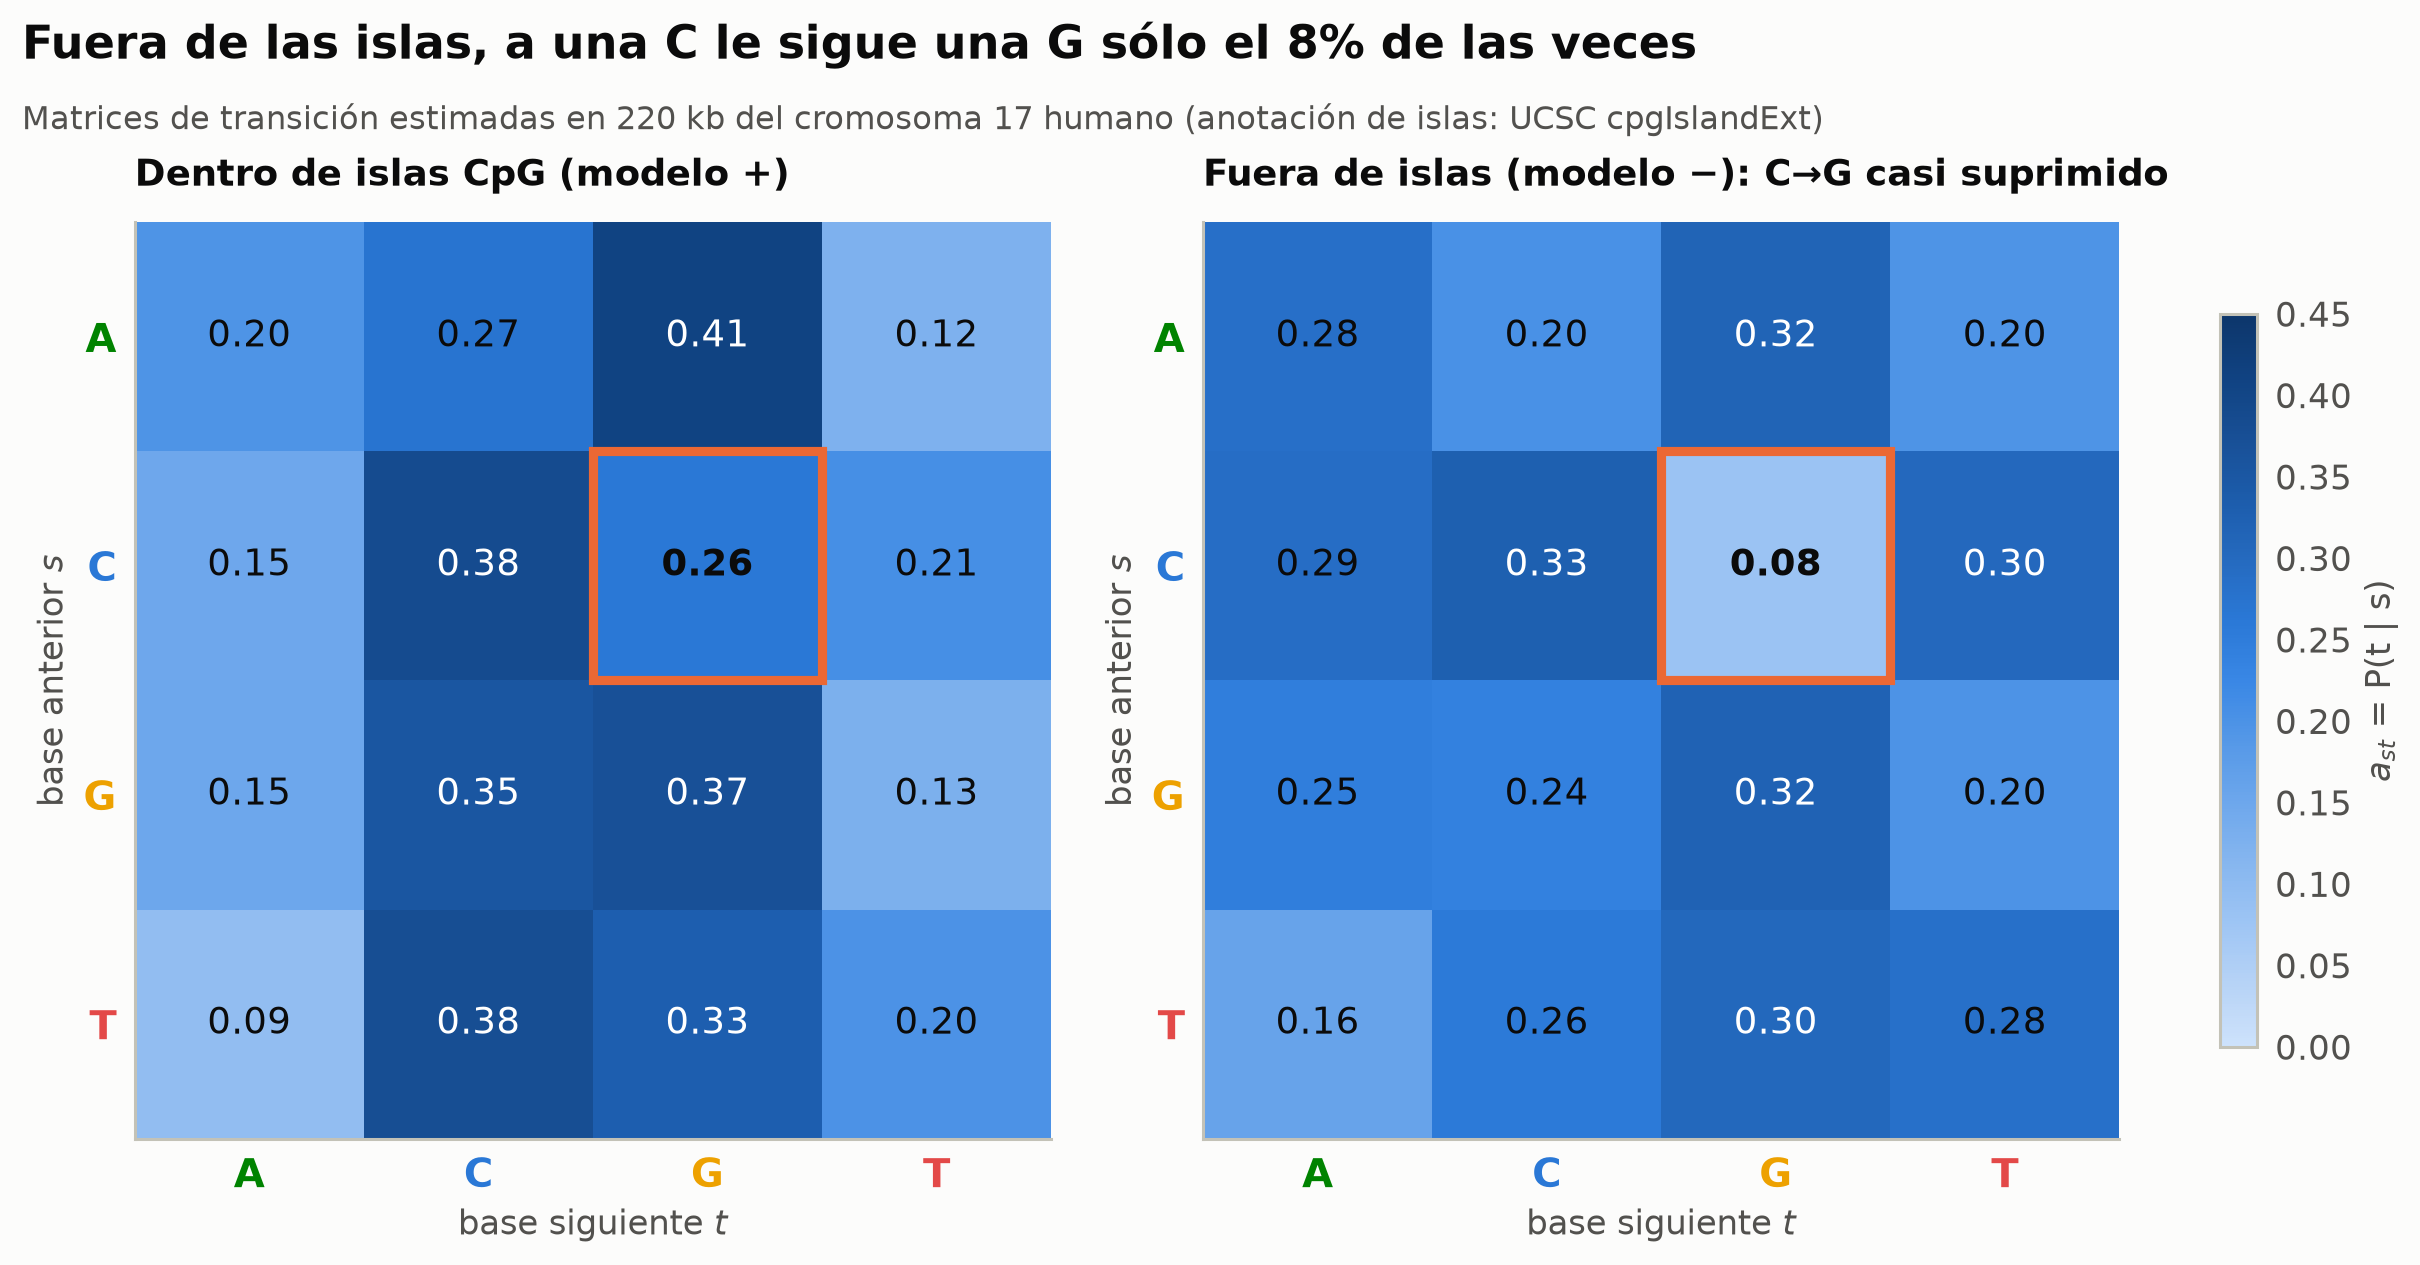

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.9))
for ax, k, name in zip(axes, [1, 0], ["Dentro de islas CpG (modelo +)", "Fuera de islas (modelo −): C→G casi suprimido"]):
    im = ax.imshow(markov[k], cmap=ec.CMAP_SEQ, vmin=0, vmax=0.45)
    for s in range(4):
        for t in range(4):
            v = markov[k, s, t]
            ax.text(t, s, f"{v:.2f}", ha="center", va="center", fontsize=12,
                    color="white" if v > 0.3 else ec.INK, fontweight="bold" if (s, t) == (1, 2) else None)
    ax.add_patch(Rectangle((1.5, 0.5), 1, 1, fill=False, ec=ec.ORANGE, lw=3))
    ax.set_xticks(range(4), list(BASES)); ax.set_yticks(range(4), list(BASES))
    for lbl in ax.get_xticklabels() + ax.get_yticklabels():
        lbl.set_color(ec.NUC_COLORS[lbl.get_text()]); lbl.set_fontweight("bold"); lbl.set_fontsize(13)
    ax.set_xlabel("base siguiente $t$"); ax.set_ylabel("base anterior $s$")
    ax.grid(False); ax.set_title(name, fontsize=12)
fig.colorbar(im, ax=axes, shrink=0.8, label="$a_{st}$ = P(t | s)")
ec.fig_title(fig, f"Fuera de las islas, a una C le sigue una G sólo el {markov[0, 1, 2]:.0%} de las veces",
             "Matrices de transición estimadas en 220 kb del cromosoma 17 humano (anotación de islas: UCSC cpgIslandExt)")
plt.show()

> 🔎 **Qué observamos.** Las dos matrices son parecidas en casi todo, **salvo en la casilla C→G** (recuadro naranja):
> dentro de una isla, a una C le sigue una G aproximadamente una de cada cuatro veces; fuera, menos de una de cada
> diez. Estos números son casi idénticos a los que Durbin y colaboradores publicaron en 1998 con otro conjunto de
> secuencias humanas: la supresión de CpG es una regla general del genoma.

### Ejemplo a mano: ¿de dónde viene `CGCG`?

Con dos cadenas de Márkov podemos preguntar **cuál de las dos explica mejor** una secuencia. Para `CGCG`, redondeando
los valores de las matrices (la primera base cuesta $\tfrac14$ en ambos modelos y se cancela):

$$
\frac{P(\texttt{CGCG}\mid +)}{P(\texttt{CGCG}\mid -)} =
\frac{a^+_{CG}\,a^+_{GC}\,a^+_{CG}}{a^-_{CG}\,a^-_{GC}\,a^-_{CG}}
\approx \frac{0.26 \times 0.35 \times 0.26}{0.08 \times 0.24 \times 0.08} \approx 16
$$

Es unas **16 veces** más probable que `CGCG` venga de una isla. Como estos cocientes se vuelven astronómicos en
secuencias largas, se trabaja con su logaritmo en base 2, el **puntaje log-odds** en bits:

$$
S(x) \;=\; \log_2 \frac{P(x\mid +)}{P(x\mid -)} \;=\; \sum_{i=2}^{L} \log_2 \frac{a^+_{x_{i-1}x_i}}{a^-_{x_{i-1}x_i}}
\;=\; \sum_{i=2}^{L} \beta_{x_{i-1}x_i}
$$

| Símbolo | Significado |
|---|---|
| $a^+_{st},\ a^-_{st}$ | transiciones de los modelos "isla" y "no isla" |
| $\beta_{st}$ | aporte (en bits) de cada par: positivo si el par es típico de islas |
| $S(x) > 0$ | la secuencia se parece más a una isla |

Para `CGCG`: $S = 2\log_2(0.26/0.08) + \log_2(0.35/0.24) \approx 2(1.70) + 0.54 \approx 3.9$ bits ($2^{3.9} \approx 16$ ✔).

> 🤔 **Antes de ejecutar, prediga:** si tomamos ventanas de 200 pb **dentro** de islas y **fuera** de ellas (en la
> parte de prueba) y calculamos $S/L$ (bits por base), ¿se separarán por completo los dos histogramas?

β (bits):
       A     C     G     T
A -0.54  0.42  0.37 -0.67
C -0.97  0.24  1.71 -0.56
G -0.72  0.57  0.22 -0.63
T -0.76  0.57  0.11 -0.50

S(CGCG) = 3.98 bits


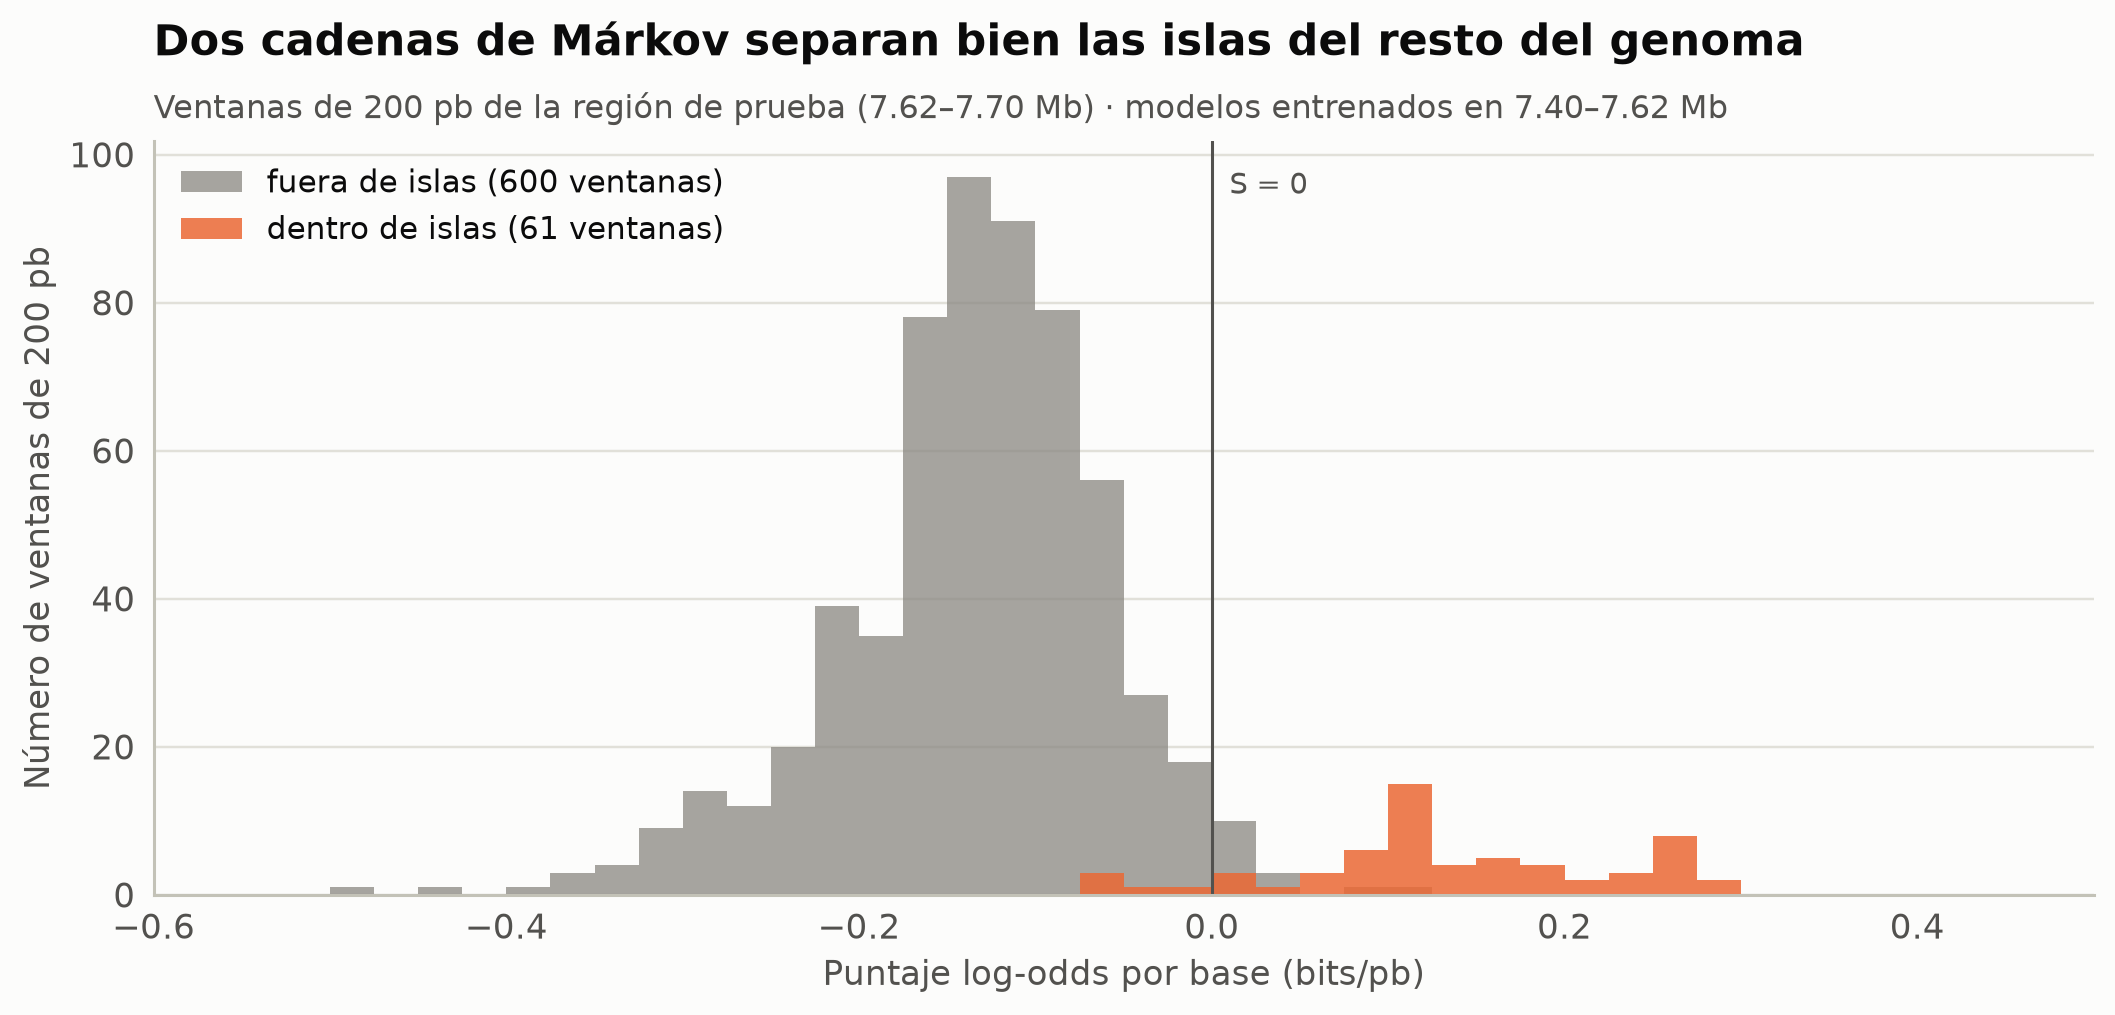

In [5]:
beta = np.log2(markov[1] / markov[0])            # bits por par (matriz 4 x 4)
print("β (bits):\n", pd.DataFrame(beta, index=list(BASES), columns=list(BASES)).round(2))
print(f"\nS(CGCG) = {beta[1, 2] + beta[2, 1] + beta[1, 2]:.2f} bits")

def window_scores(x, starts, w=200):
    return np.array([beta[x[s:s + w - 1], x[s + 1:s + w]].sum() / w for s in starts])

W = 200
test_isl = islands[islands.start >= SPLIT]
inside_starts = [s for a, b in zip(test_isl.start, test_isl.end) for s in range(a, b - W, 25)]
outside_pool = np.array([s for s in range(SPLIT, len(chr17) - W, 97) if in_island[s:s + W].sum() == 0])
outside_starts = rng.choice(outside_pool, size=600, replace=False)
s_in, s_out = window_scores(x_all, inside_starts), window_scores(x_all, outside_starts)

fig, ax = plt.subplots(figsize=(9.5, 4.5))
bins = np.linspace(-0.55, 0.45, 41)
ax.hist(s_out, bins=bins, color=ec.MUTED, alpha=0.75, label=f"fuera de islas ({len(s_out)} ventanas)")
ax.hist(s_in, bins=bins, color=ec.ORANGE, alpha=0.85, label=f"dentro de islas ({len(s_in)} ventanas)")
ax.axvline(0, color=ec.INK_2, lw=1)
ax.text(0.01, ax.get_ylim()[1] * 0.93, "S = 0", color=ec.INK_2, fontsize=9.5)
ax.set_xlabel("Puntaje log-odds por base (bits/pb)"); ax.set_ylabel("Número de ventanas de 200 pb")
ax.legend(loc="upper left")
ec.title(ax, "Dos cadenas de Márkov separan bien las islas del resto del genoma",
         "Ventanas de 200 pb de la región de prueba (7.62–7.70 Mb) · modelos entrenados en 7.40–7.62 Mb")
plt.show()

> 🔎 **Qué observamos.** Las ventanas de islas tienen puntajes positivos y las del resto negativos, con muy poco
> solapamiento. Pero note la trampa: **nosotros elegimos las ventanas sabiendo dónde estaban las islas**. En un
> genoma nuevo no sabemos dónde empieza ni dónde termina una isla, ni si la ventana de 200 pb es demasiado corta o
> demasiado larga. Lo que realmente queremos es un modelo que, mientras recorre la secuencia, pueda **cambiar de
> "modo"** (isla ↔ no isla) y nos diga **dónde** ocurren los cambios. Ese modelo es un HMM.

✅ **Compruebe su comprensión.** Usando la matriz $\beta$ impresa arriba, ¿qué par de bases aporta más bits a favor
de "isla"? ¿Y cuál aporta más en contra? (Respuesta: CG es, con mucho, el más positivo; los pares ricos en A/T, como
TA o AT, son los más negativos.)

## 2. Lo que no se ve: el casino deshonesto como HMM

Antes de volver al genoma, usemos el ejemplo clásico del libro de Durbin, Eddy, Krogh y Mitchison (1998). Un casino
usa casi siempre un **dado justo**, pero de vez en cuando, sin avisar, lo cambia por un **dado cargado** que saca 6 la
mitad de las veces. Usted sólo ve los números que salen: **la identidad del dado está oculta**.

Es exactamente el problema de las islas CpG: vemos las bases (los "números del dado"), pero no vemos si estamos dentro
o fuera de una isla (el "dado que se está usando"). Un **modelo oculto de Márkov** tiene dos capas:

* una **cadena de Márkov de estados ocultos** $\pi_1 \pi_2 \dots \pi_L$ (justo/cargado; isla/no isla), con
  probabilidades de **transición** $a_{kl}$;
* en cada posición, el estado **emite** un símbolo visible $x_i$ con probabilidad de **emisión** $e_k(b)$.

| Parámetro | Dado justo (F) | Dado cargado (L) |
|---|---|---|
| $e(1), \dots, e(5)$ | $1/6$ cada uno | $0.1$ cada uno |
| $e(6)$ | $1/6$ | $0.5$ |
| Seguir con el mismo dado | $a_{FF} = 0.95$ | $a_{LL} = 0.90$ |
| Cambiar de dado | $a_{FL} = 0.05$ | $a_{LF} = 0.10$ |

(F de *fair*, L de *loaded*: conservamos las letras del libro.) Con $a_{FF} = 0.95$, el dado justo se usa en rachas
de $1/(1 - 0.95) = 20$ tiradas en promedio, y el cargado en rachas de $1/(1-0.9) = 10$.

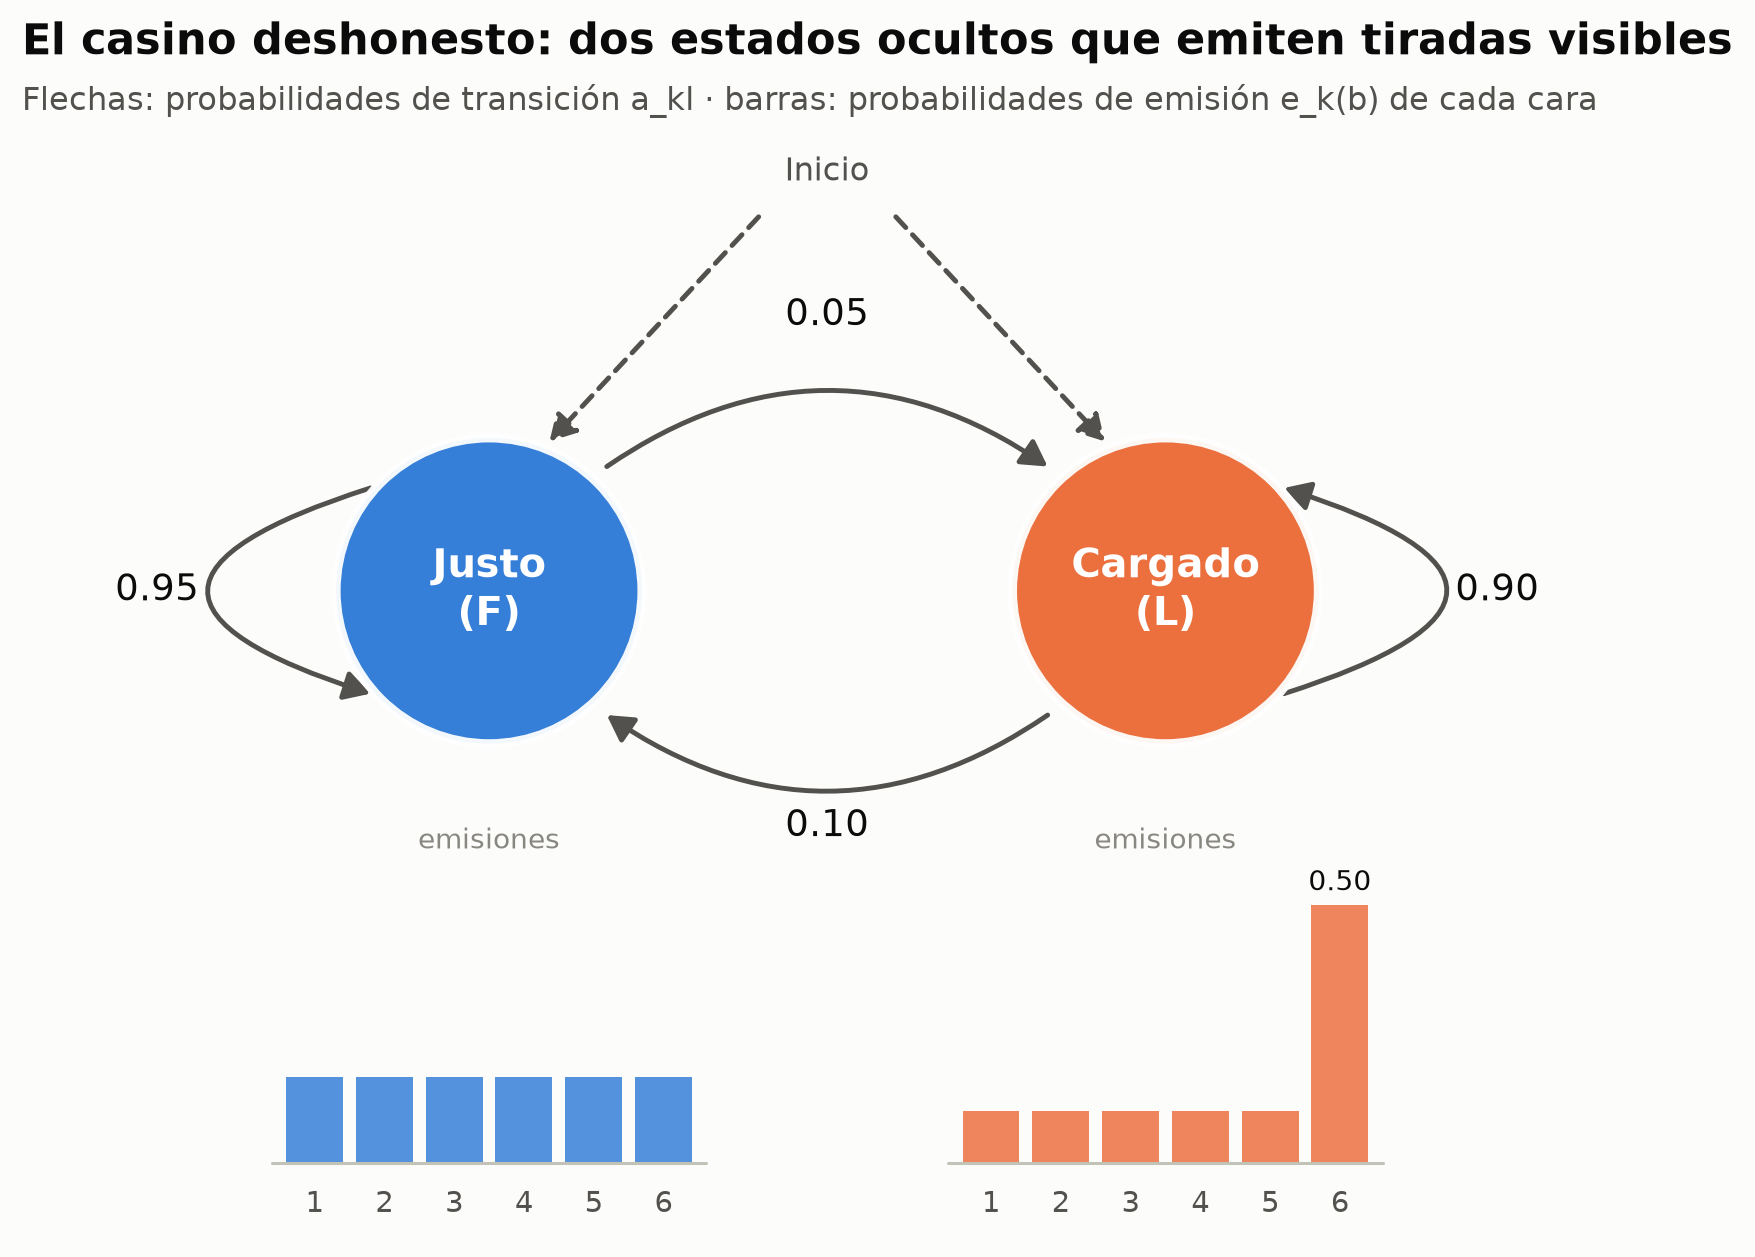

In [6]:
STATES = ["F", "L"]                       # 0 = justo (fair), 1 = cargado (loaded)
STATE_NAMES = ["Justo", "Cargado"]
STATE_COLORS = [ec.BLUE, ec.ORANGE]
A_casino = np.array([[0.95, 0.05],
                     [0.10, 0.90]])
E_casino = np.array([[1/6] * 6,
                     [0.1] * 5 + [0.5]])
p0_casino = np.array([0.5, 0.5])

def draw_two_state_hmm(ax, A, emissions, symbols, names, colors, title_start="Inicio"):
    """Diagrama profesional de un HMM de dos estados: círculos, flechas con probabilidades y barras de emisión."""
    ax.set_xlim(0, 10); ax.set_ylim(-0.4, 6.4); ax.set_aspect("equal"); ax.axis("off")
    centers, r = [(2.9, 3.6), (7.1, 3.6)], 0.95
    for (cx, cy), name, col in zip(centers, names, colors):
        ax.add_patch(Circle((cx, cy), r, fc=col, ec="white", lw=3, alpha=0.95, zorder=3))
        ax.text(cx, cy, name, ha="center", va="center", color="white", fontsize=13, fontweight="bold", zorder=4)
    arrow = dict(arrowstyle="-|>,head_length=7,head_width=4", color=ec.INK_2, lw=1.6, zorder=2)
    # transiciones entre estados (arriba F→L, abajo L→F)
    ax.add_patch(FancyArrowPatch((3.6, 4.35), (6.4, 4.35), connectionstyle="arc3,rad=-0.35", **arrow))
    ax.add_patch(FancyArrowPatch((6.4, 2.85), (3.6, 2.85), connectionstyle="arc3,rad=-0.35", **arrow))
    ax.text(5, 5.25, f"{A[0, 1]:.2f}", ha="center", fontsize=12, color=ec.INK)
    ax.text(5, 2.25, f"{A[1, 0]:.2f}", ha="center", va="top", fontsize=12, color=ec.INK)
    # auto-transiciones (bucles hacia afuera)
    ax.add_patch(FancyArrowPatch((2.2, 4.25), (2.2, 2.95), connectionstyle="arc3,rad=1.6", **arrow))
    ax.add_patch(FancyArrowPatch((7.8, 2.95), (7.8, 4.25), connectionstyle="arc3,rad=1.6", **arrow))
    ax.text(1.1, 3.6, f"{A[0, 0]:.2f}", ha="right", va="center", fontsize=12, color=ec.INK)
    ax.text(8.9, 3.6, f"{A[1, 1]:.2f}", ha="left", va="center", fontsize=12, color=ec.INK)
    # nodo de inicio
    ax.text(5, 6.2, title_start, ha="center", va="center", fontsize=10.5, color=ec.INK_2,
            bbox=dict(boxstyle="round,pad=0.35", fc=ec.SURFACE, ec=ec.BASELINE))
    for cx, _ in centers:
        ax.add_patch(FancyArrowPatch((5 - 0.4 * np.sign(5 - cx), 5.95), (cx + 0.35 * np.sign(5 - cx), 4.5),
                                     connectionstyle="arc3,rad=0", linestyle=(0, (3, 2)), **arrow))
    # barras de emisión debajo de cada estado
    for (cx, _), em, col in zip(centers, emissions, colors):
        n = len(symbols); width = 2.6 / n; x0 = cx - 1.3
        ax.plot([x0 - 0.05, x0 + 2.65], [0.05, 0.05], color=ec.BASELINE, lw=1)
        for j, (sym, p) in enumerate(zip(symbols, em)):
            h = 1.6 * p / max(max(e) for e in emissions)
            ax.add_patch(Rectangle((x0 + j * width + 0.04, 0.05), width - 0.08, h, fc=col, alpha=0.8))
            ax.text(x0 + (j + 0.5) * width, -0.12, sym, ha="center", va="top", fontsize=9.5, color=ec.INK_2)
            if p == max(em) and p > min(em):
                ax.text(x0 + (j + 0.5) * width, 0.1 + h, f"{p:.2f}", ha="center", va="bottom", fontsize=9, color=ec.INK)
        ax.text(cx, 2.0, "emisiones", ha="center", fontsize=9, color=ec.MUTED)

fig, ax = plt.subplots(figsize=(8.5, 5.6))
draw_two_state_hmm(ax, A_casino, E_casino, list("123456"), ["Justo\n(F)", "Cargado\n(L)"], STATE_COLORS)
ec.title(ax, "El casino deshonesto: dos estados ocultos que emiten tiradas visibles",
         "Flechas: probabilidades de transición a_kl · barras: probabilidades de emisión e_k(b) de cada cara")
plt.show()

Simulemos una noche en el casino: 300 tiradas. El generador elige el estado siguiente según la fila de $A$ del
estado actual, y la cara según la fila de $E$ del nuevo estado.

Tiradas : 44626263236346141334645621635443162663663666452666365663643543413113156636663615 …
Dado    : LLLFFFFFFFFFFFLLLLFFFFFFFFFFFFLLLLLLLLLLLLLFFFLLLLLLLLLLLFFFFFFFFFFFFFLLLLLLFFFF …
Fracción de tiempo con el dado cargado: 25%


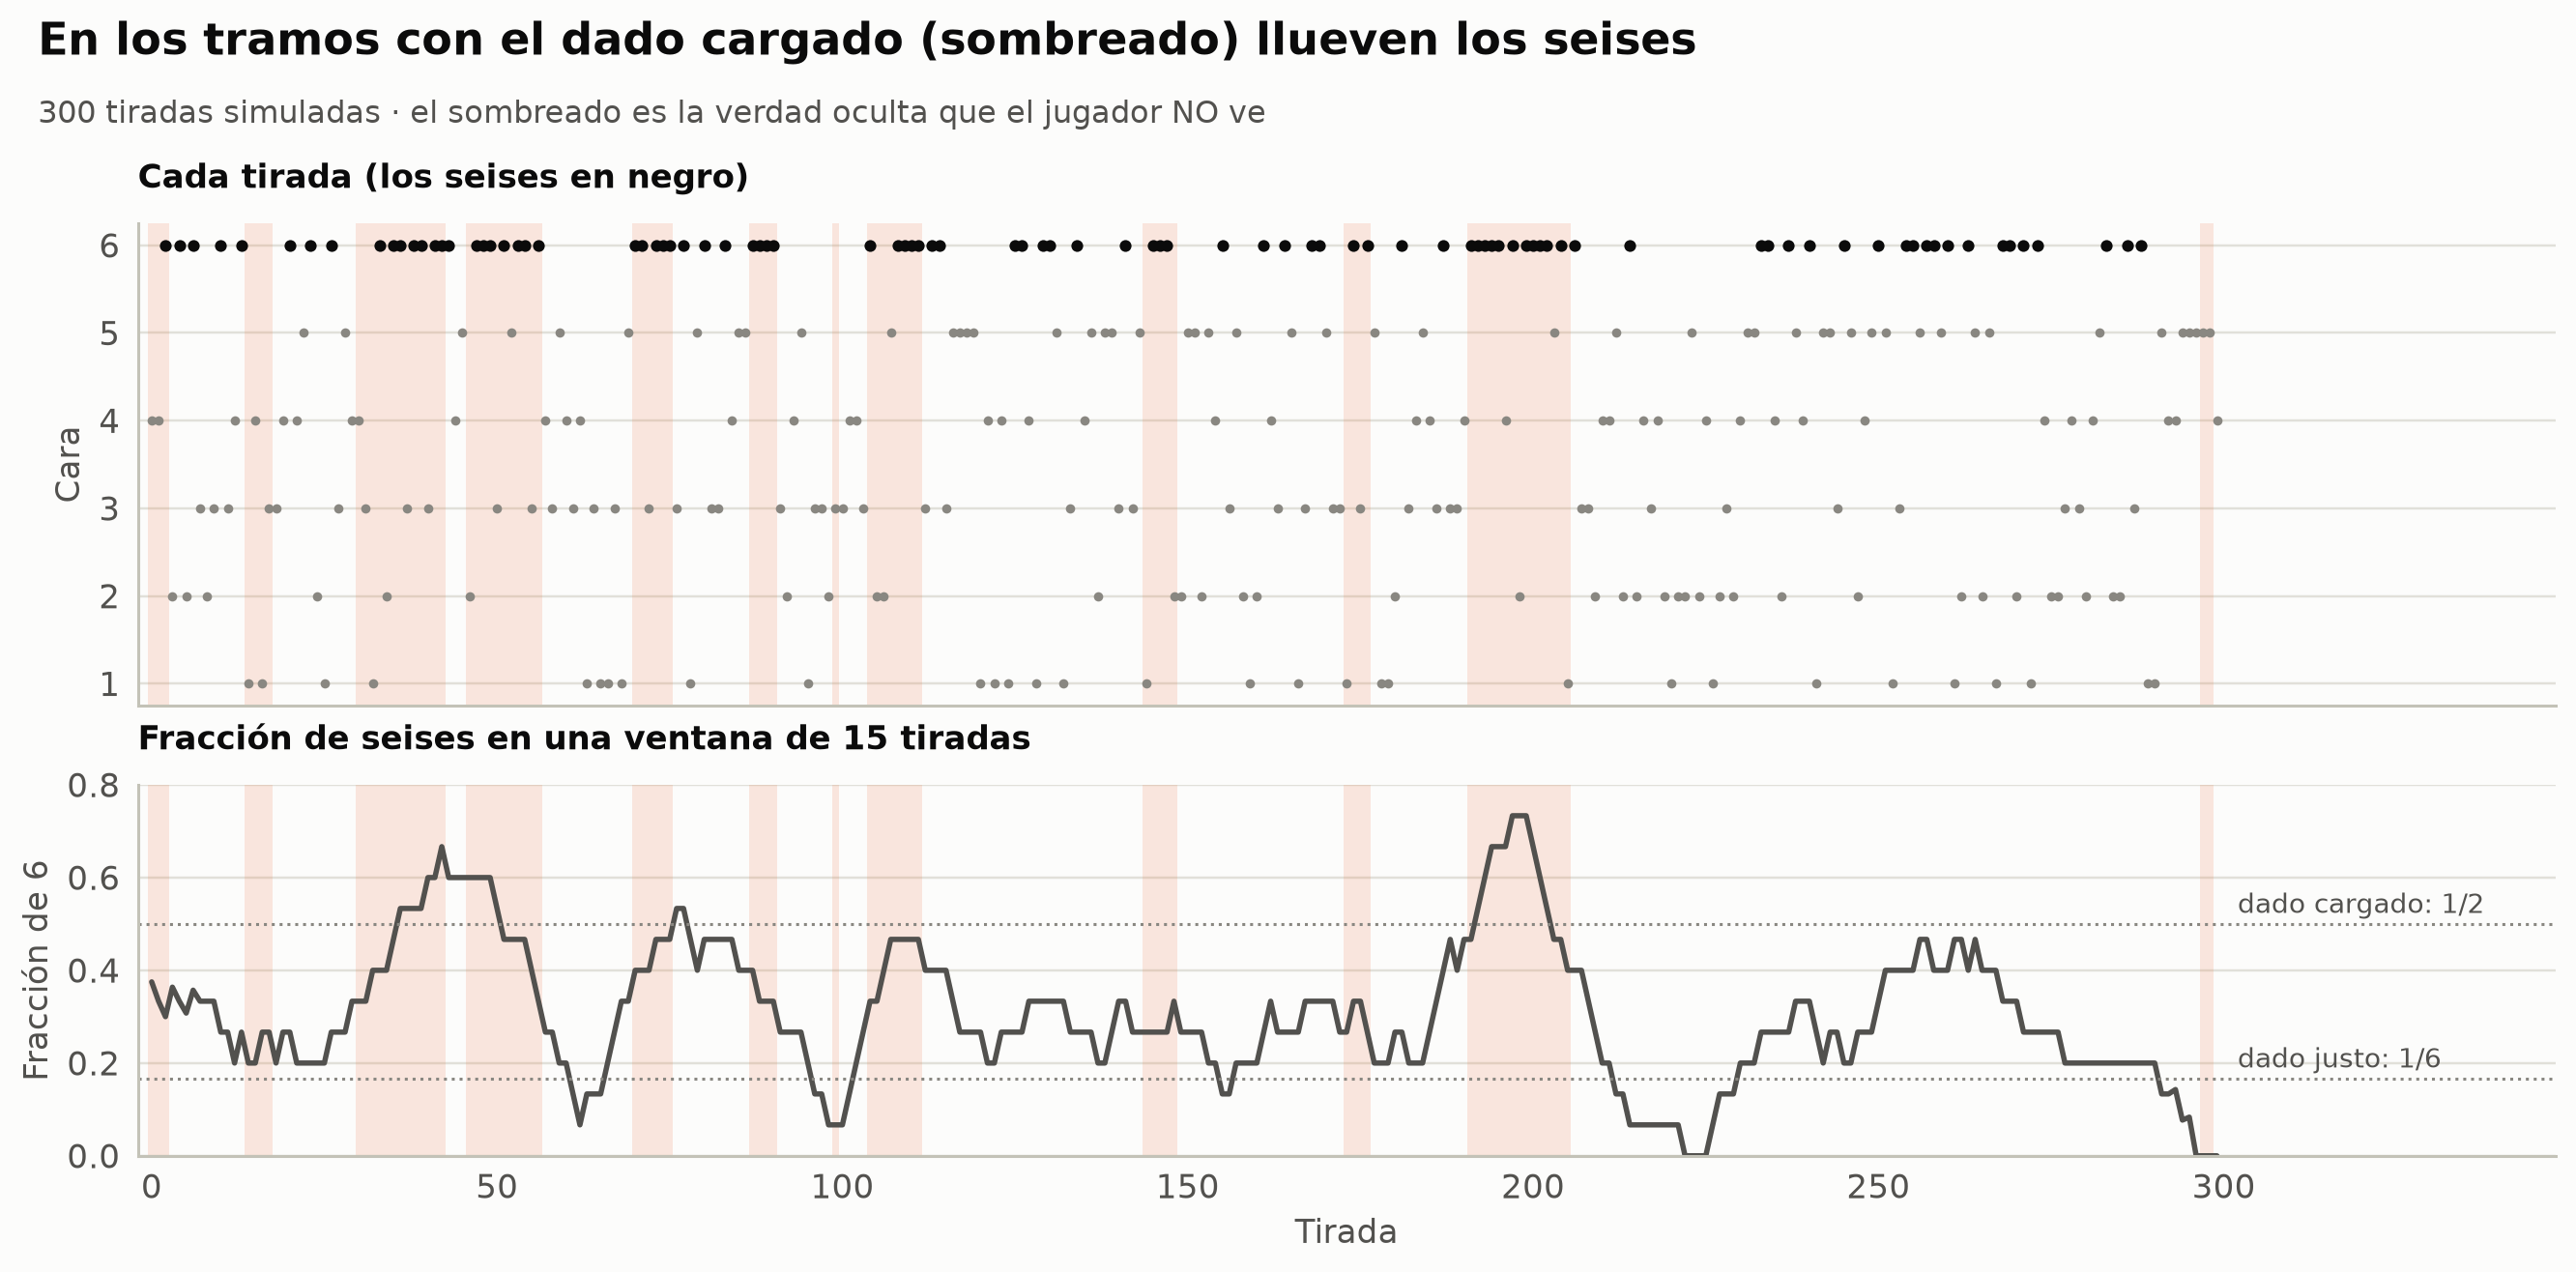

In [7]:
def simulate_hmm(A, E, p0, n, rng):
    """Genera n pasos de un HMM: devuelve (estados ocultos, símbolos emitidos)."""
    states = np.empty(n, dtype=int); symbols = np.empty(n, dtype=int)
    states[0] = rng.choice(len(p0), p=p0)
    for i in range(n):
        if i > 0:
            states[i] = rng.choice(len(p0), p=A[states[i - 1]])
        symbols[i] = rng.choice(E.shape[1], p=E[states[i]])
    return states, symbols

true_states, rolls = simulate_hmm(A_casino, E_casino, p0_casino, 300, np.random.default_rng(27))
print("Tiradas :", "".join(str(r + 1) for r in rolls[:80]), "…")
print("Dado    :", "".join(STATES[s] for s in true_states[:80]), "…")
print(f"Fracción de tiempo con el dado cargado: {true_states.mean():.0%}")

def segments(path, value=1):
    """Intervalos [inicio, fin) donde path == value."""
    d = np.diff(np.r_[0, (np.asarray(path) == value).astype(int), 0])
    return list(zip(np.where(d == 1)[0], np.where(d == -1)[0]))

fig, (ax, ax2) = plt.subplots(2, 1, figsize=(12, 5.2), sharex=True, height_ratios=[1.3, 1])
six = rolls == 5
for a in (ax, ax2):
    for s, e in segments(true_states):
        a.axvspan(s - 0.5, e - 0.5, color=ec.ORANGE, alpha=0.15, lw=0)
ax.scatter(np.where(~six)[0], rolls[~six] + 1, s=10, color=ec.MUTED, zorder=3)
ax.scatter(np.where(six)[0], rolls[six] + 1, s=16, color=ec.INK, zorder=3)
ax.set_yticks(range(1, 7)); ax.set_ylabel("Cara")
ax.set_title("Cada tirada (los seises en negro)", fontsize=11, loc="left")
frac6 = pd.Series(six.astype(float)).rolling(15, center=True, min_periods=5).mean()
ax2.plot(np.arange(len(rolls)), frac6, color=ec.INK_2, lw=1.8)
for yv, lbl in [(1 / 6, "dado justo: 1/6"), (0.5, "dado cargado: 1/2")]:
    ax2.axhline(yv, color=ec.MUTED, ls=":", lw=1)
    ax2.text(len(rolls) + 2, yv + 0.01, lbl, fontsize=9, color=ec.INK_2, va="bottom")
ax2.set_ylim(0, 0.8); ax2.set_ylabel("Fracción de 6")
ax2.set_title("Fracción de seises en una ventana de 15 tiradas", fontsize=11, loc="left")
ax2.set_xlim(-2, len(rolls) + 48); ax2.set_xlabel("Tirada")
ec.fig_title(fig, "En los tramos con el dado cargado (sombreado) llueven los seises",
             "300 tiradas simuladas · el sombreado es la verdad oculta que el jugador NO ve")
plt.show()

> 🔎 **Qué observamos.** A simple vista uno "intuye" los tramos cargados porque se amontonan los seises (puntos
> negros), pero los bordes son borrosos: un dado justo también saca tres seises seguidos de vez en cuando. Necesitamos
> una regla precisa.

### La probabilidad de un camino de estados

Si **supiéramos** el camino oculto $\pi$, la probabilidad conjunta de las tiradas y del camino sería el producto de
todas las flechas recorridas y de todas las emisiones:

$$
P(x, \pi) \;=\; a_{0\,\pi_1}\; \prod_{i=1}^{L} e_{\pi_i}(x_i)\; a_{\pi_i\,\pi_{i+1}}
$$

| Símbolo | Significado |
|---|---|
| $x_i$ | el símbolo observado en la posición $i$ (la cara del dado, la base) |
| $\pi_i$ | el estado oculto en la posición $i$ (F o L) |
| $a_{0\,k}$ | probabilidad de empezar en el estado $k$ (aquí $\tfrac12$ para cada uno) |
| $a_{kl}$ | probabilidad de transición del estado $k$ al $l$ (el último factor $a_{\pi_L\pi_{L+1}}$ se omite: no modelamos un final) |
| $e_k(b)$ | probabilidad de que el estado $k$ emita el símbolo $b$ |

### Ejemplo a mano: tres tiradas, ocho caminos

Observamos $x = (6, 6, 1)$. Para el camino LLL:

$$
P(x, \text{LLL}) = \underbrace{0.5}_{a_{0L}} \cdot \underbrace{0.5}_{e_L(6)} \cdot \underbrace{0.9}_{a_{LL}} \cdot
\underbrace{0.5}_{e_L(6)} \cdot \underbrace{0.9}_{a_{LL}} \cdot \underbrace{0.1}_{e_L(1)} = 0.010125
$$

Y para FFF: $0.5 \cdot \tfrac16 \cdot 0.95 \cdot \tfrac16 \cdot 0.95 \cdot \tfrac16 \approx 0.002089$. El camino LLL es
casi cinco veces más probable, aunque la última tirada (un 1) "prefiera" al dado justo: cambiar de dado cuesta
($a_{LF} = 0.1$), y un solo 1 no alcanza para justificar el cambio.

  camino  P(x, π)
0    LLL 0.010125
1    FFF 0.002089
2    LLF 0.001875
3    LFF 0.000660
4    FLL 0.000188
5    FFL 0.000066
6    FLF 0.000035
7    LFL 0.000021

Suma de los 8 caminos = P(x) = 0.015058


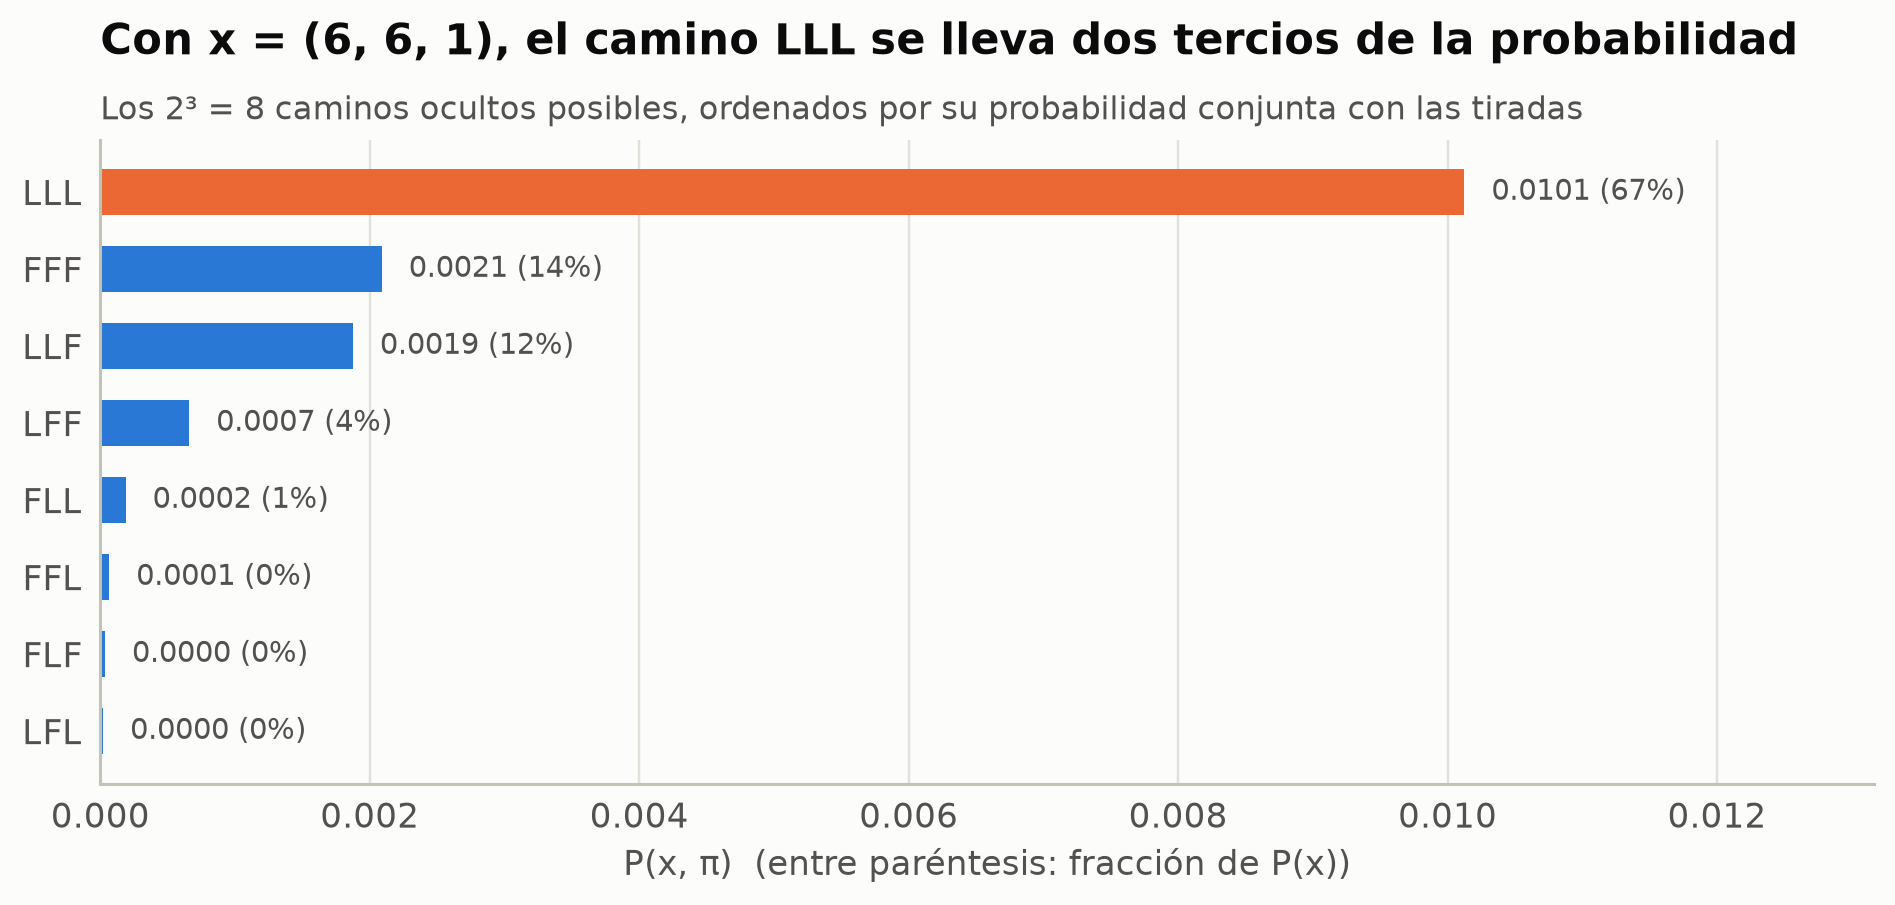

In [8]:
def joint_prob(x, path, A, E, p0):
    p = p0[path[0]] * E[path[0], x[0]]
    for i in range(1, len(x)):
        p *= A[path[i - 1], path[i]] * E[path[i], x[i]]
    return p

x_hand = np.array([6, 6, 1]) - 1                     # caras 6, 6, 1 (índices desde 0)
paths = list(itertools.product([0, 1], repeat=3))
path_probs = pd.DataFrame({"camino": ["".join(STATES[k] for k in p) for p in paths],
                           "P(x, π)": [joint_prob(x_hand, p, A_casino, E_casino, p0_casino) for p in paths]})
path_probs = path_probs.sort_values("P(x, π)", ascending=False).reset_index(drop=True)
P_x_hand = path_probs["P(x, π)"].sum()
print(path_probs.to_string(float_format=lambda v: f"{v:.6f}"))
print(f"\nSuma de los 8 caminos = P(x) = {P_x_hand:.6f}")

fig, ax = plt.subplots(figsize=(8.5, 4))
cols = [ec.ORANGE if i == 0 else ec.BLUE for i in range(len(path_probs))]
ax.barh(path_probs["camino"], path_probs["P(x, π)"], color=cols, height=0.6)
for i, v in enumerate(path_probs["P(x, π)"]):
    ax.text(v + 0.0002, i, f"{v:.4f} ({v / P_x_hand:.0%})", va="center", fontsize=9.5, color=ec.INK_2)
ax.invert_yaxis(); ax.set_xlim(0, path_probs["P(x, π)"].max() * 1.3)
ax.grid(axis="y", visible=False); ax.grid(axis="x", visible=True)
ax.set_xlabel("P(x, π)  (entre paréntesis: fracción de P(x))")
ax.set_yticks(range(len(path_probs)), path_probs["camino"], family="DejaVu Sans Mono")
ec.title(ax, "Con x = (6, 6, 1), el camino LLL se lleva dos tercios de la probabilidad",
         "Los 2³ = 8 caminos ocultos posibles, ordenados por su probabilidad conjunta con las tiradas")
plt.show()

> 🔎 **Qué observamos.** Enumerar funciona con 3 tiradas (8 caminos), pero con $L$ tiradas hay $2^L$ caminos: para
> nuestras 300 tiradas, $2^{300} \approx 10^{90}$, más que átomos en el universo observable. Igual que en la Lección 3.2,
> la salvación es la **programación dinámica**: guardar en una tabla la mejor forma de llegar a cada estado en cada
> posición, y reutilizarla.

✅ **Compruebe su comprensión.** ¿Cuánto vale la suma de las ocho probabilidades? (Respuesta: $P(x) \approx 0.01506$,
la probabilidad total de observar 6, 6, 1 **sumando sobre todos los caminos**; la calcularemos luego sin enumerar, con
el algoritmo Forward.)

## 3. El algoritmo de Viterbi: el camino más probable

Andrew Viterbi propuso en 1967 (para decodificar señales de radio con ruido) la idea que usaremos: **el mejor camino
que termina en el estado $l$ en la posición $i$ tiene que pasar por el mejor camino que termina en algún estado $k$
en la posición $i-1$**. Es el mismo razonamiento de Needleman-Wunsch: si la mejor ruta de Bogotá a Lima pasa por Quito,
entonces su tramo Bogotá–Quito es también la mejor ruta entre esas dos ciudades.

Guardamos en una tabla $v_k(i)$ = la probabilidad del **mejor** camino que explica $x_1\dots x_i$ y termina en el
estado $k$. Como multiplicar cientos de probabilidades pequeñas produce números que la computadora redondea a 0
(*underflow*: $0.1^{400} = 10^{-400}$ ya no cabe en un `float`), trabajamos con **logaritmos**, y los productos se
vuelven sumas:

$$
\boxed{\;V_l(i) \;=\; \log e_l(x_i) \;+\; \max_{k}\big[\, V_k(i-1) + \log a_{kl} \,\big]\;}
\qquad
\text{ptr}_i(l) = \arg\max_k \big[ V_k(i-1) + \log a_{kl} \big]
$$

$$
V_k(1) = \log a_{0k} + \log e_k(x_1)
\qquad\qquad
\pi^*_L = \arg\max_k V_k(L), \qquad \pi^*_{i-1} = \text{ptr}_i(\pi^*_i)
$$

| Símbolo | Significado |
|---|---|
| $V_l(i)$ | logaritmo de la probabilidad del mejor camino para $x_1 \dots x_i$ que termina en el estado $l$ |
| $\log a_{kl}$ | costo (en log) de pasar del estado $k$ al $l$ |
| $\log e_l(x_i)$ | costo (en log) de que el estado $l$ emita el símbolo observado |
| $\text{ptr}_i(l)$ | el **predecesor**: de qué estado venía el mejor camino (la "flecha" del *traceback*) |
| $\pi^*$ | el **camino de Viterbi**, recuperado de atrás hacia adelante siguiendo los predecesores |

### Ejemplo a mano: $x = (6, 6, 1)$ con logaritmos naturales

Valores útiles: $\ln\tfrac12 = -0.693$, $\ln\tfrac16 = -1.792$, $\ln 0.1 = -2.303$, $\ln 0.95 = -0.051$,
$\ln 0.9 = -0.105$, $\ln 0.05 = -2.996$.

| | $i = 1$ (sale 6) | $i = 2$ (sale 6) | $i = 3$ (sale 1) |
|---|---|---|---|
| $V_F$ | $-0.693 - 1.792 = \mathbf{-2.485}$ | $-1.792 + \max(-2.485 - 0.051,\ -1.386 - 2.303) = \mathbf{-4.328}$ ← F | $-1.792 + \max(-4.328 - 0.051,\ -2.185 - 2.303) = \mathbf{-6.171}$ ← F |
| $V_L$ | $-0.693 - 0.693 = \mathbf{-1.386}$ | $-0.693 + \max(-2.485 - 2.996,\ -1.386 - 0.105) = \mathbf{-2.185}$ ← L | $-2.303 + \max(-4.328 - 2.996,\ -2.185 - 0.105) = \mathbf{-4.593}$ ← L |

El máximo final es $V_L(3) = -4.593$, y $e^{-4.593} = 0.010125$: exactamente la probabilidad del camino LLL que
calculamos enumerando. El *traceback* sigue las flechas ← L, ← L: el camino de Viterbi es **LLL**, sin haber
enumerado los ocho caminos.

In [9]:
def viterbi(log_p0, log_A, log_emis):
    """Algoritmo de Viterbi en espacio logarítmico.
    log_emis: matriz n x K con log e_k(x_i) ya evaluado en cada posición (sirve para cualquier alfabeto).
    Devuelve (camino, V, punteros, log P del mejor camino)."""
    n, K = log_emis.shape
    V = np.empty((n, K)); ptr = np.zeros((n, K), dtype=np.int8)
    V[0] = log_p0 + log_emis[0]
    for i in range(1, n):
        cand = V[i - 1][:, None] + log_A          # cand[k, l] = V_k(i-1) + log a_kl
        ptr[i] = cand.argmax(axis=0)
        V[i] = cand.max(axis=0) + log_emis[i]
    path = np.empty(n, dtype=int); path[-1] = V[-1].argmax()
    for i in range(n - 1, 0, -1):                 # traceback
        path[i - 1] = ptr[i, path[i]]
    return path, V, ptr, V[-1].max()

logA_c, logE_c, logp0_c = np.log(A_casino), np.log(E_casino), np.log(p0_casino)
path_hand, V_hand, ptr_hand, best = viterbi(logp0_c, logA_c, logE_c[:, x_hand].T)
print("Tabla V (filas = tiradas 6, 6, 1; columnas = F, L):\n", V_hand.round(3))
print("Camino de Viterbi:", "".join(STATES[k] for k in path_hand), f"· P = e^{best:.3f} = {np.exp(best):.6f}")

Tabla V (filas = tiradas 6, 6, 1; columnas = F, L):
 [[-2.485 -1.386]
 [-4.328 -2.185]
 [-6.171 -4.593]]
Camino de Viterbi: LLL · P = e^-4.593 = 0.010125


## 4. 🎬 Animación: la trellis de Viterbi se llena

La tabla de Viterbi se suele dibujar como una **trellis** (enrejado): una columna por posición y una fila por estado.
Veámosla llenarse con 25 tiradas elegidas para que haya un tramo cargado en el medio. Cada casilla muestra $V_k(i)$ y
una flecha gris desde su predecesor; al final, el *traceback* recorre las flechas de derecha a izquierda (en naranja).

![La trellis de Viterbi se llena columna a columna; al final el traceback (naranja) recupera el camino F…L…F](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-04-msa-motivos-hmm/4.3_viterbi_trellis.gif)

*La trellis de Viterbi se llena columna a columna; al final el traceback (naranja) recupera el camino F…L…F*

In [10]:
demo = np.array([int(c) - 1 for c in "2413531246616666166524135"])
demo_path, demo_V, demo_ptr, _ = viterbi(logp0_c, logA_c, logE_c[:, demo].T)
n = len(demo)
ys = {0: 1.0, 1: 0.0}                                   # fila de cada estado en el dibujo

fig, ax = plt.subplots(figsize=(12, 3.9))
ax.set_xlim(-1.6, n - 0.4); ax.set_ylim(-0.75, 1.95); ax.axis("off")
for k in (0, 1):
    ax.text(-0.95, ys[k], STATE_NAMES[k], ha="right", va="center", fontsize=11, color=STATE_COLORS[k], fontweight="bold")
for i, r in enumerate(demo):
    ax.text(i, 1.62, str(r + 1), ha="center", va="center", fontsize=12, family="DejaVu Sans Mono",
            color=ec.INK if r == 5 else ec.MUTED, fontweight="bold" if r == 5 else None)
ax.text(-0.95, 1.62, "tirada", ha="right", va="center", fontsize=10, color=ec.INK_2)
boxes, labels, arrows = {}, {}, []
for i in range(n):
    for k in (0, 1):
        boxes[i, k] = FancyBboxPatch((i - 0.4, ys[k] - 0.2), 0.8, 0.4, boxstyle="round,pad=0.02",
                                     fc=ec.SURFACE, ec=ec.GRID, lw=1, zorder=2)
        ax.add_patch(boxes[i, k])
        labels[i, k] = ax.text(i, ys[k], "", ha="center", va="center", fontsize=7.8, color=ec.INK, zorder=3)
status = ax.text(-1.5, -0.6, "", fontsize=10.5, color=ec.INK, va="center")
ax.set_title("Trellis de Viterbi para el casino deshonesto (valores: ln de la probabilidad)", fontsize=12, loc="left")

trace_order = list(range(n - 1, -1, -1))
frames = n + n + 2

def update(f):
    if f < n:                                          # llenado de la columna f
        i = f
        best_col = demo_V[i].argmax()
        for k in (0, 1):
            labels[i, k].set_text(f"{demo_V[i, k]:.1f}")
            boxes[i, k].set_facecolor(STATE_COLORS[k] if k == best_col else ec.SURFACE)
            boxes[i, k].set_alpha(0.25 if k == best_col else 1)
            if i > 0:
                p = demo_ptr[i, k]
                arrows.append(ax.annotate("", (i - 0.42, ys[k]), (i - 0.58, ys[p]),
                                          arrowprops=dict(arrowstyle="->", color=ec.MUTED, lw=0.9), zorder=1))
        status.set_text(f"Llenando la columna {i + 1}/{n}: cada casilla elige su mejor predecesor")
    elif f < 2 * n:                                    # traceback
        t = f - n
        i = trace_order[t]
        k = demo_path[i]
        boxes[i, k].set_edgecolor(ec.ORANGE); boxes[i, k].set_linewidth(2.5)
        if i < n - 1:
            ax.annotate("", (i + 0.42, ys[k]), (i + 0.58, ys[demo_path[i + 1]]),
                        arrowprops=dict(arrowstyle="-", color=ec.ORANGE, lw=2.5), zorder=4)
        status.set_text(f"Traceback: posición {i + 1} → estado {STATE_NAMES[k]}")
    else:
        status.set_text("Camino de Viterbi: " + "".join(STATES[k] for k in demo_path))
    return list(labels.values()) + [status]

ec.animate(fig, update, frames=frames, interval=180, name="4.3_viterbi_trellis")

▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

> 🔎 **Qué observamos.** Los valores decrecen de izquierda a derecha (cada tirada multiplica por un número menor que 1,
> es decir, **suma** un logaritmo negativo). El estado ganador en cada columna (casilla sombreada) cambia varias veces,
> pero el camino final **no** es simplemente "el ganador de cada columna": el traceback puede pasar por casillas que
> localmente perdían, porque lo que importa es el camino **completo**. El camino entra al dado cargado justo en el
> primer par de seises (tirada 10) y regresa al justo después del último 6 (tirada 19): los unos aislados de las
> tiradas 12 y 17 no bastan para "pagar" dos cambios de dado.

### Explorador interactivo de la matriz de Viterbi

Ahora con las 300 tiradas simuladas. El color de cada casilla es $V_k(i) - \max_j V_j(i)$: cuánto **pierde** ese estado
frente al mejor en esa posición (0 = es el mejor). Pase el cursor para ver el valor exacto, la tirada y el predecesor
elegido; use el deslizador inferior para hacer zoom. La línea negra es el camino de Viterbi.

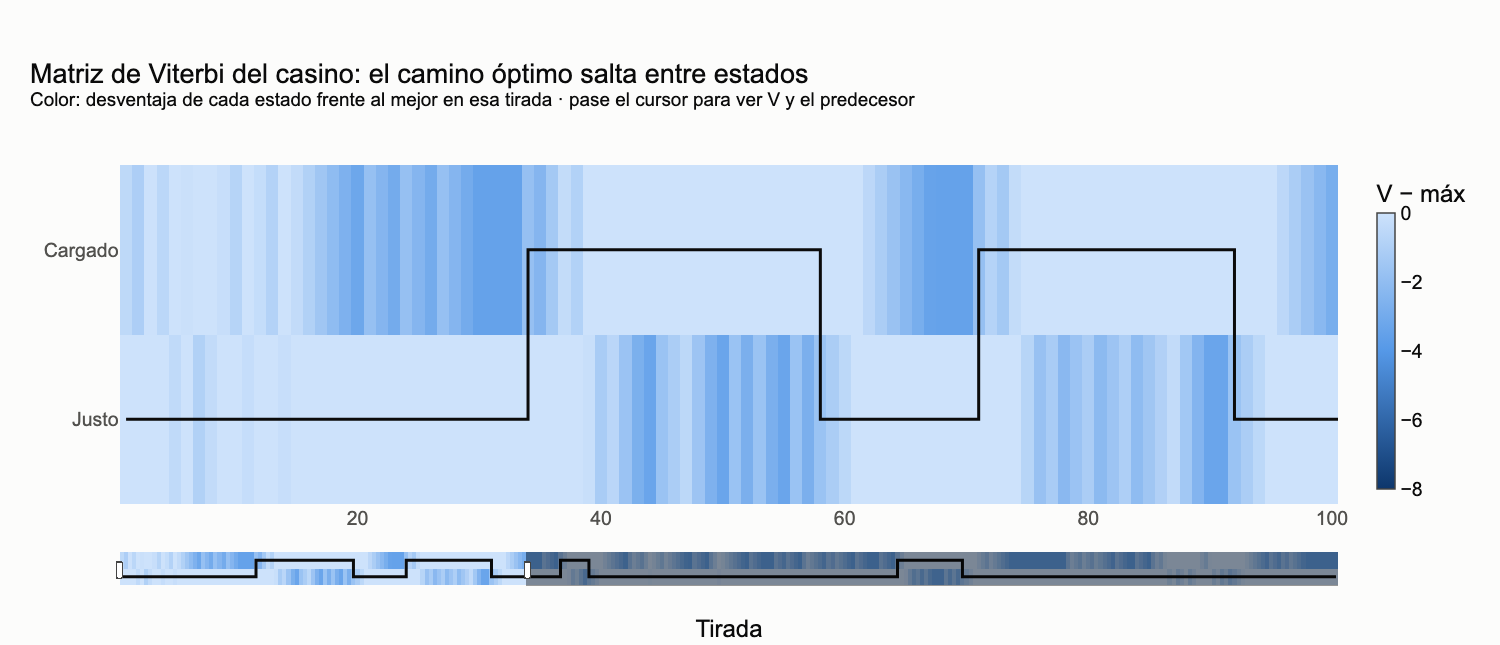

In [11]:
vit_path, V_full, ptr_full, _ = viterbi(logp0_c, logA_c, logE_c[:, rolls].T)
gap = V_full - V_full.max(axis=1, keepdims=True)
pos = np.arange(1, len(rolls) + 1)
custom = np.stack([np.stack([V_full[:, k], np.array(STATES)[ptr_full[:, k]], rolls + 1,
                             np.array(STATES)[true_states]], axis=-1) for k in (0, 1)])
custom[:, 0, 1] = "—"                                   # la primera posición no tiene predecesor

fig = go.Figure(go.Heatmap(
    z=gap.T, x=pos, y=STATE_NAMES, customdata=custom, zmin=-8, zmax=0,
    colorscale=[[0, ec.SEQ_BLUE[12]], [0.5, ec.SEQ_BLUE[5]], [1, ec.SEQ_BLUE[0]]],
    colorbar=dict(title="V − máx", thickness=12),
    hovertemplate=("Tirada %{x}: sale <b>%{customdata[2]}</b><br>Estado %{y}<br>V = %{customdata[0]:.2f}"
                   "<br>Predecesor: %{customdata[1]}<br>Dado real: %{customdata[3]}<extra></extra>")))
fig.add_scatter(x=pos, y=[STATE_NAMES[k] for k in vit_path], mode="lines", line=dict(color=ec.INK, width=2, shape="hv"),
                name="camino de Viterbi", hoverinfo="skip")
fig.update_layout(
    title=dict(text="Matriz de Viterbi del casino: el camino óptimo salta entre estados<br>"
                    "<sup>Color: desventaja de cada estado frente al mejor en esa tirada · pase el cursor para ver V y el predecesor</sup>"),
    xaxis=dict(title="Tirada", rangeslider=dict(visible=True, thickness=0.08), range=[0.5, 100.5]),
    yaxis=dict(title=""), height=430, margin=dict(t=110, l=80, r=40, b=40),
    legend=dict(orientation="h", yanchor="bottom", y=1.02, x=1, xanchor="right"))
fig.show()

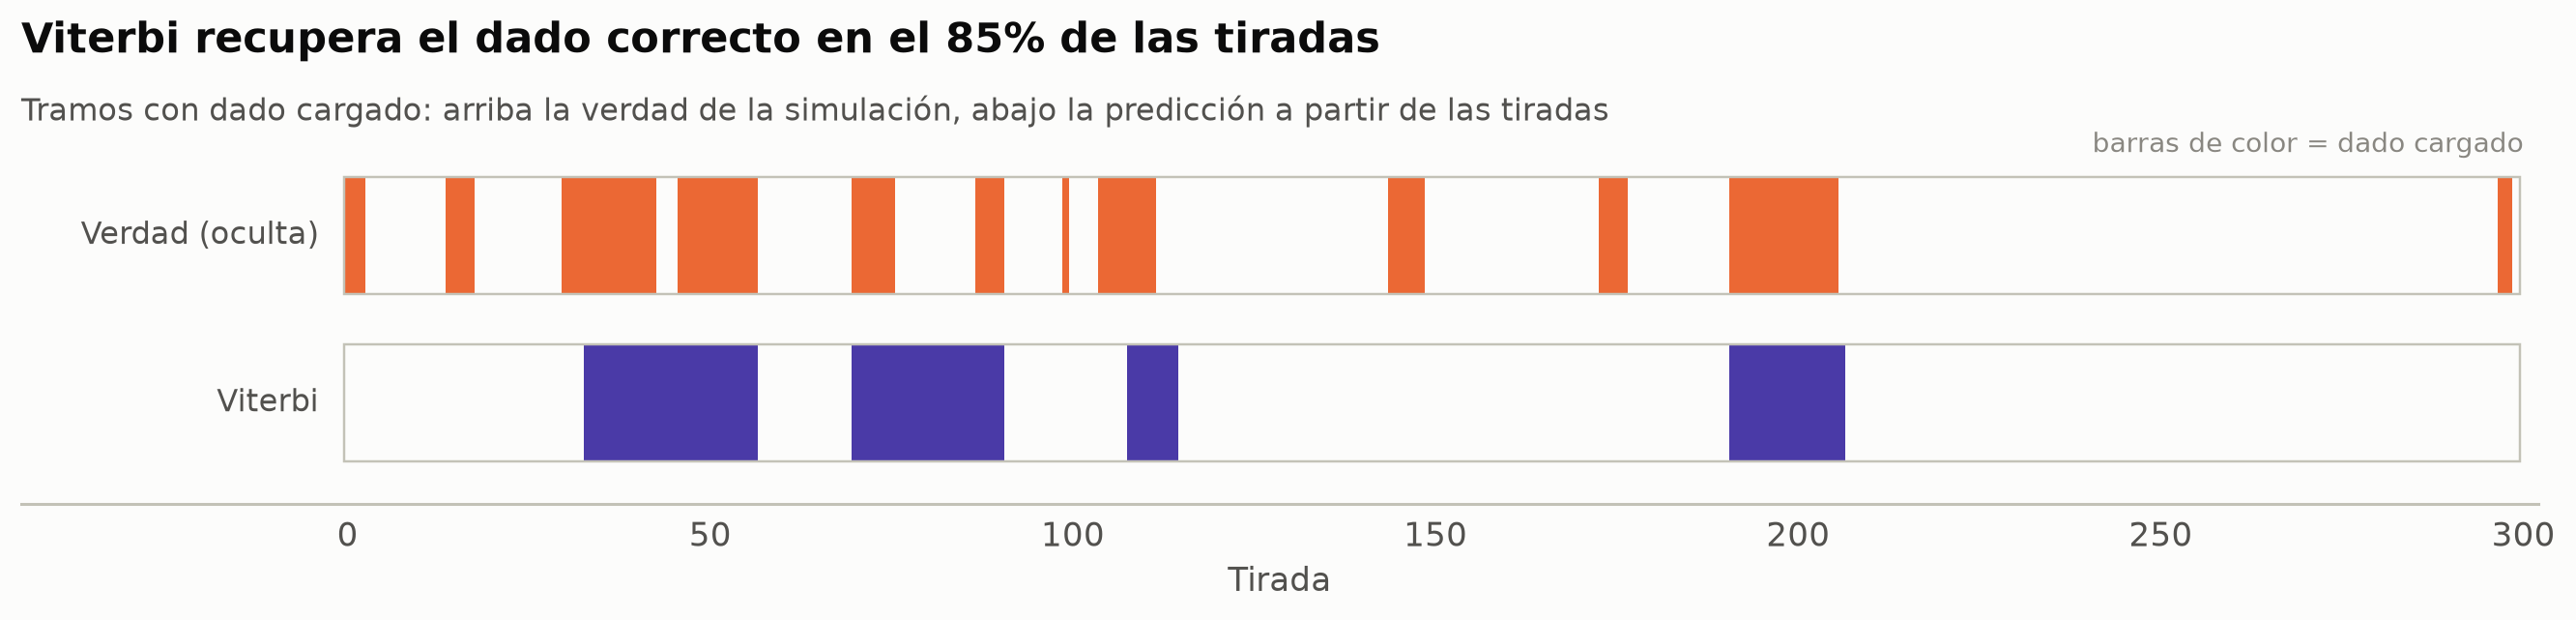

In [12]:
def state_strip(ax, path, y, label, color):
    for s, e in segments(path):
        ax.add_patch(Rectangle((s - 0.5, y - 0.35), e - s, 0.7, fc=color, lw=0))
    ax.add_patch(Rectangle((-0.5, y - 0.35), len(path), 0.7, fc="none", ec=ec.BASELINE, lw=0.8))
    ax.text(-4, y, label, ha="right", va="center", fontsize=10.5, color=ec.INK_2)

acc = (vit_path == true_states).mean()
fig, ax = plt.subplots(figsize=(12, 2.8))
state_strip(ax, true_states, 1, "Verdad (oculta)", ec.ORANGE)
state_strip(ax, vit_path, 0, "Viterbi", ec.VIOLET)
ax.set_xlim(-45, len(rolls) + 2); ax.set_ylim(-0.6, 1.6); ax.set_yticks([]); ax.grid(False)
ax.spines["left"].set_visible(False); ax.set_xlabel("Tirada")
ax.text(len(rolls), 1.5, "barras de color = dado cargado", ha="right", fontsize=9, color=ec.MUTED)
ec.title(ax, f"Viterbi recupera el dado correcto en el {acc:.0%} de las tiradas",
         "Tramos con dado cargado: arriba la verdad de la simulación, abajo la predicción a partir de las tiradas")
plt.show()

> 🔎 **Qué observamos.** Viterbi encuentra los tramos cargados largos y se equivoca sobre todo en los **bordes** (unas
> pocas tiradas antes o después) y en tramos cargados **muy cortos**, que no dejan suficientes seises como evidencia.
> Viterbi da una única respuesta "en blanco y negro"; no dice **cuán seguro** está en cada posición. Para eso
> necesitamos sumar sobre todos los caminos.

✅ **Compruebe su comprensión.** Si el casino cambiara de dado con más frecuencia ($a_{FL} = 0.2$, $a_{LF} = 0.3$),
¿esperaría que el camino de Viterbi tuviera tramos más largos o más cortos? ¿Por qué? (Respuesta: más cortos: cambiar
de estado "cuesta" menos en log, así que menos seises bastan para justificar el cambio.)

## 5. Forward, Backward y la probabilidad posterior

Viterbi responde "¿cuál es **el** mejor camino?". Pero con 300 tiradas hay muchísimos caminos casi tan buenos como el
mejor (que difieren, por ejemplo, en dónde exactamente empieza un tramo cargado). Una pregunta más útil es:
**"en la tirada $i$, ¿qué probabilidad hay de que se estuviera usando el dado cargado, considerando todos los caminos
posibles?"**. Es la **probabilidad posterior** $P(\pi_i = k \mid x)$.

Para calcularla necesitamos dos tablas. La de **Forward** es idéntica a la de Viterbi, cambiando **máximo por suma**:
en vez de quedarnos con el mejor predecesor, sumamos la contribución de todos.

$$
f_l(i) \;=\; e_l(x_i) \sum_k f_k(i-1)\, a_{kl}
\qquad f_k(1) = a_{0k}\,e_k(x_1)
\qquad P(x) = \sum_k f_k(L)
$$

La de **Backward** recorre la secuencia al revés y resume "todo lo que viene después":

$$
b_k(i) \;=\; \sum_l a_{kl}\, e_l(x_{i+1})\, b_l(i+1) \qquad b_k(L) = 1
\qquad\qquad
\boxed{\;P(\pi_i = k \mid x) \;=\; \frac{f_k(i)\; b_k(i)}{P(x)}\;}
$$

| Símbolo | Significado |
|---|---|
| $f_k(i)$ | probabilidad de observar $x_1 \dots x_i$ **y** estar en el estado $k$ en la posición $i$ (sumando sobre todos los caminos previos) |
| $b_k(i)$ | probabilidad de observar $x_{i+1} \dots x_L$ **dado** que en la posición $i$ estamos en el estado $k$ |
| $P(x)$ | probabilidad total de las observaciones bajo el modelo (la **verosimilitud**) |
| $P(\pi_i = k \mid x)$ | probabilidad **posterior** de que la posición $i$ esté en el estado $k$ |

### Ejemplo a mano: Forward para $x = (6, 6, 1)$

| | $i=1$ (6) | $i=2$ (6) | $i=3$ (1) |
|---|---|---|---|
| $f_F$ | $0.5 \cdot \tfrac16 = 0.08333$ | $\tfrac16(0.08333 \cdot 0.95 + 0.25 \cdot 0.1) = 0.01736$ | $\tfrac16(0.01736 \cdot 0.95 + 0.11458 \cdot 0.1) = 0.00466$ |
| $f_L$ | $0.5 \cdot 0.5 = 0.25$ | $0.5(0.08333 \cdot 0.05 + 0.25 \cdot 0.9) = 0.11458$ | $0.1(0.01736 \cdot 0.05 + 0.11458 \cdot 0.9) = 0.01040$ |

$P(x) = 0.00466 + 0.01040 = 0.01506$: **exactamente** la suma de los ocho caminos de la sección 2, pero con sólo
$2 \times 2$ operaciones por columna en vez de enumerar $2^L$ caminos. Y como $b_k(3) = 1$, la posterior de la última
tirada es $P(\pi_3 = L \mid x) = 0.01040 / 0.01506 \approx 0.69$: aunque salió un 1, lo más probable es que el dado
cargado siguiera en la mesa.

**Un detalle práctico.** Las sumas no se llevan bien con los logaritmos, así que en vez de trabajar en log usamos
**escalado**: en cada posición dividimos $f(i)$ por su suma $c_i$ y guardamos los $c_i$. Al final
$\log P(x) = \sum_i \log c_i$, y las posteriores salen sin *underflow*.

In [13]:
def forward_backward(p0, A, emis):
    """Forward-Backward con escalado. emis: matriz n x K con e_k(x_i) (probabilidades, no logaritmos).
    Devuelve (posterior n x K, log P(x), F escalada, B escalada, factores de escala c)."""
    n, K = emis.shape
    F = np.empty((n, K)); B = np.empty((n, K)); c = np.empty(n)
    f = p0 * emis[0]; c[0] = f.sum(); F[0] = f / c[0]
    for i in range(1, n):
        f = (F[i - 1] @ A) * emis[i]
        c[i] = f.sum(); F[i] = f / c[i]
    B[-1] = 1.0
    for i in range(n - 2, -1, -1):
        B[i] = (A @ (emis[i + 1] * B[i + 1])) / c[i + 1]
    return F * B, np.log(c).sum(), F, B, c

post_hand, logP_hand, *_ = forward_backward(p0_casino, A_casino, E_casino[:, x_hand].T)
print(f"P(x) por Forward = {np.exp(logP_hand):.6f}   (enumerando los 8 caminos: {P_x_hand:.6f})")
print("Posterior P(estado | x) para las tiradas 6, 6, 1:\n", pd.DataFrame(post_hand, columns=STATE_NAMES,
      index=["tirada 1 (6)", "tirada 2 (6)", "tirada 3 (1)"]).round(3))

P(x) por Forward = 0.015058   (enumerando los 8 caminos: 0.015058)
Posterior P(estado | x) para las tiradas 6, 6, 1:
               Justo  Cargado
tirada 1 (6)  0.158    0.842
tirada 2 (6)  0.188    0.812
tirada 3 (1)  0.309    0.691


> 🤔 **Antes de ejecutar, prediga:** en las 300 tiradas, ¿dónde cree que la posterior $P(\text{cargado})$ estará cerca de
> 0.5 (máxima duda)?

log P(tiradas) = -517.35
Aciertos · Viterbi: 85.3% · posterior > 0.5: 79.3%


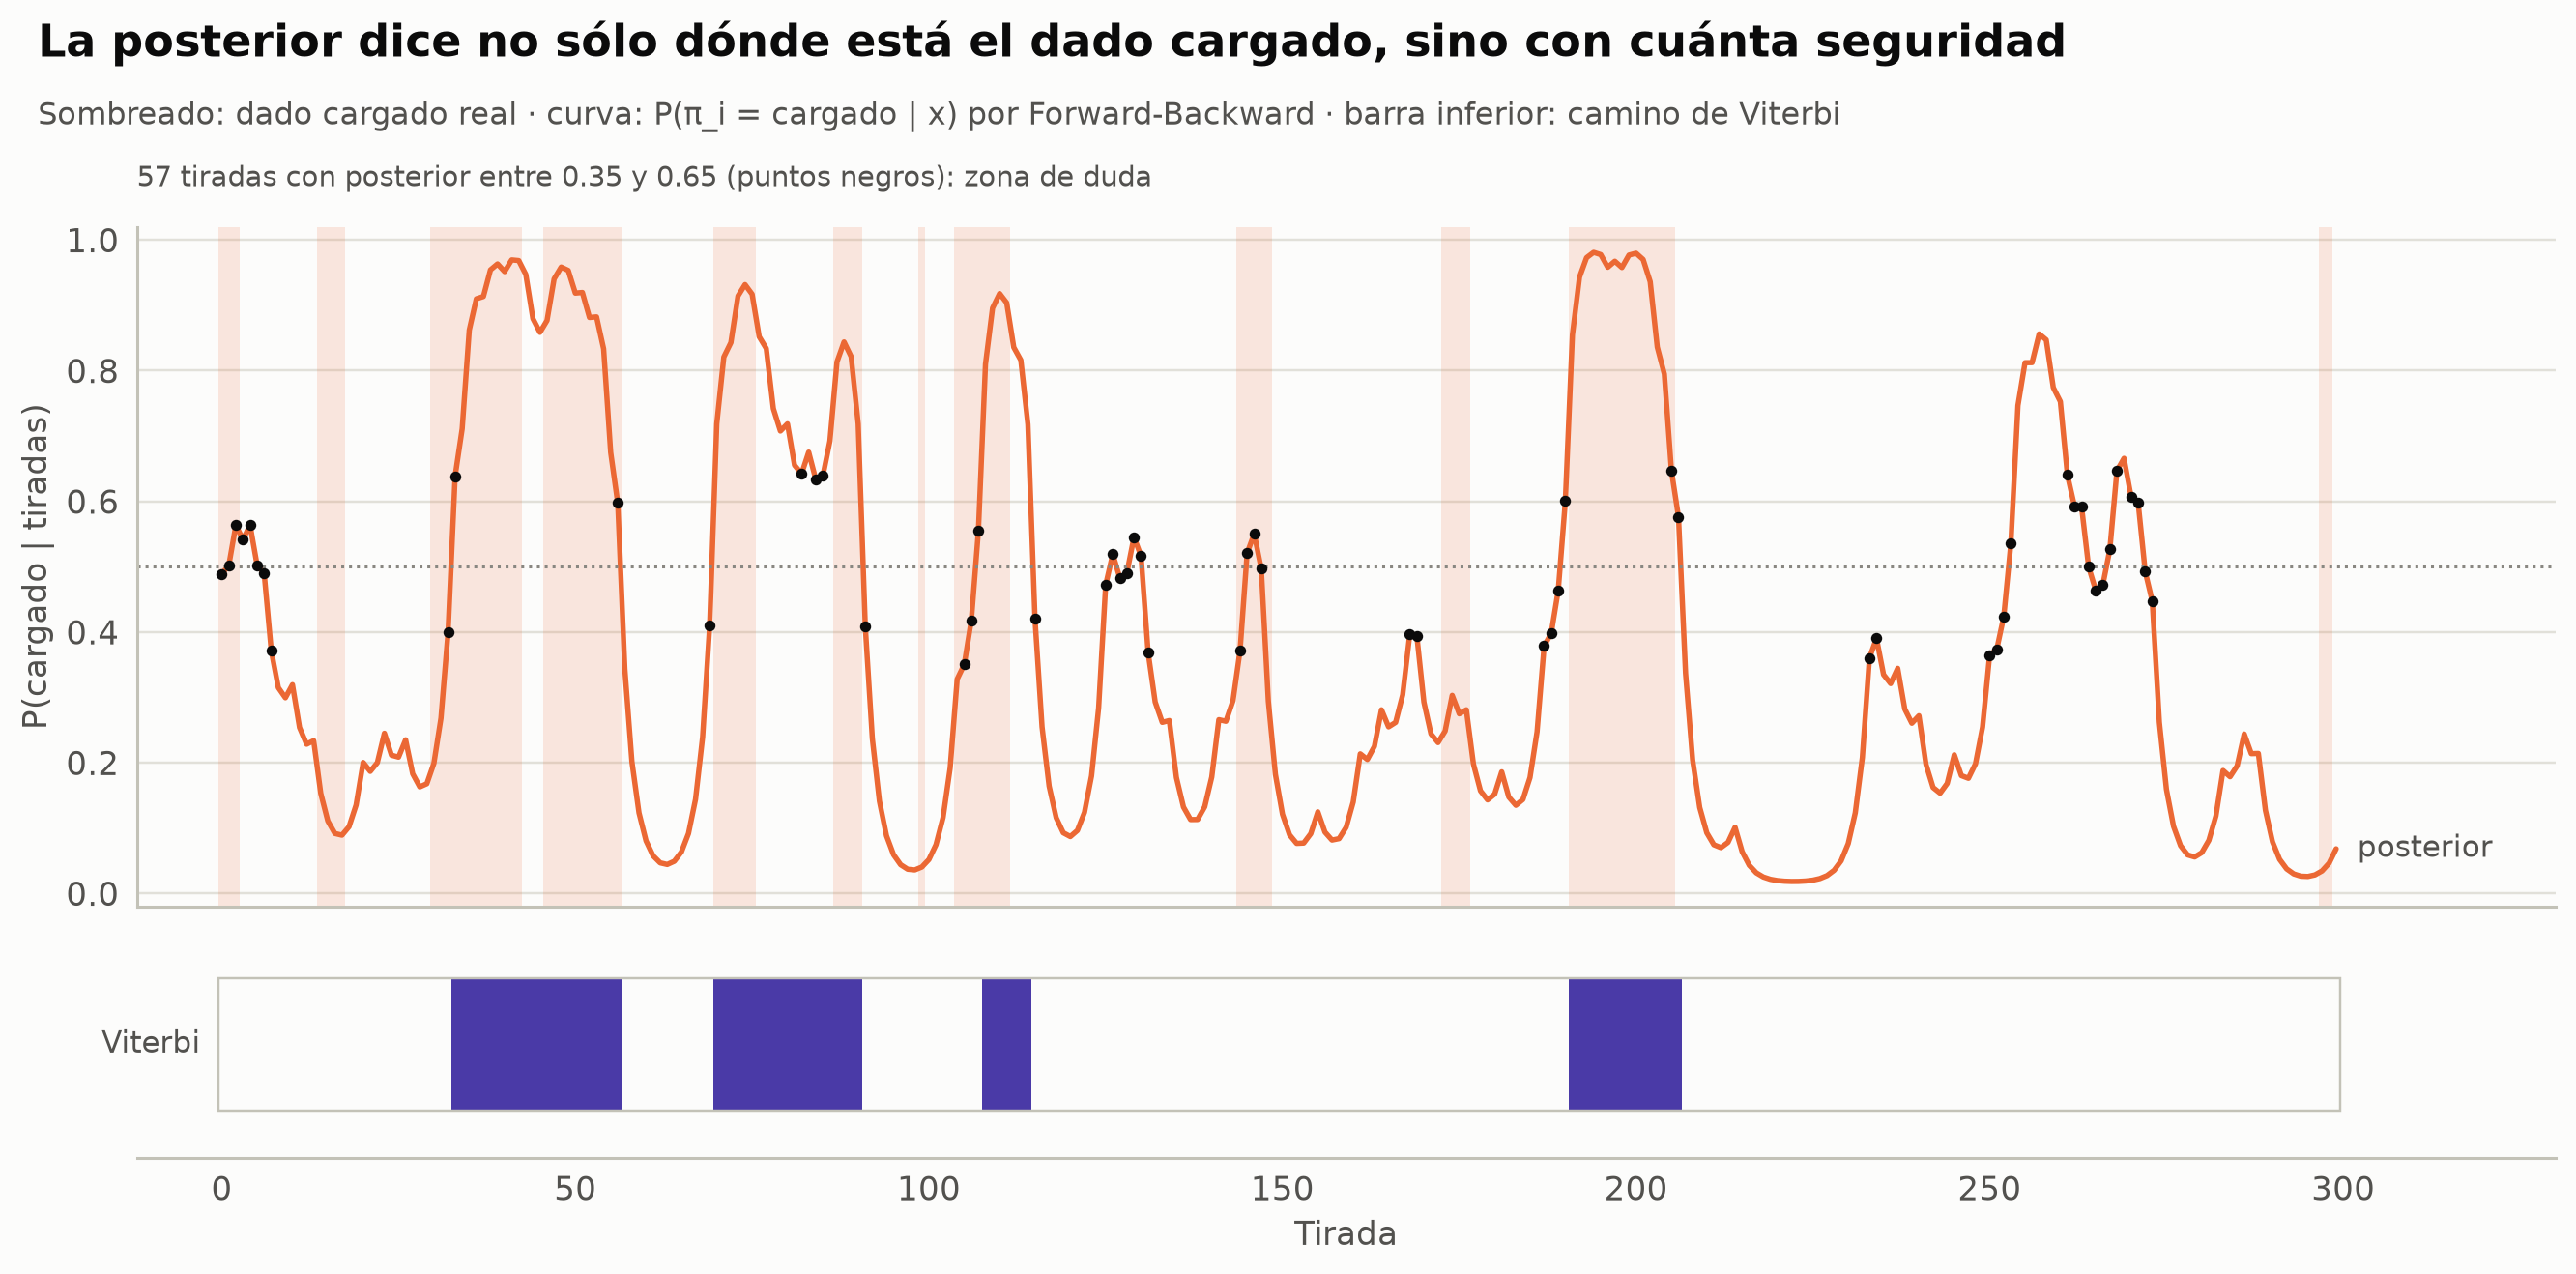

In [14]:
post, logP, *_ = forward_backward(p0_casino, A_casino, E_casino[:, rolls].T)
post_L = post[:, 1]
post_path = (post_L > 0.5).astype(int)                 # decodificación posterior
print(f"log P(tiradas) = {logP:.2f}")
print(f"Aciertos · Viterbi: {(vit_path == true_states).mean():.1%} · posterior > 0.5: {(post_path == true_states).mean():.1%}")

fig, (ax, ax2) = plt.subplots(2, 1, figsize=(12, 5.2), height_ratios=[3, 1], sharex=True)
for s, e in segments(true_states):
    ax.axvspan(s - 0.5, e - 0.5, color=ec.ORANGE, alpha=0.15, lw=0)
ax.plot(np.arange(len(rolls)), post_L, color=ec.ORANGE, lw=1.8)
ax.axhline(0.5, color=ec.MUTED, lw=1, ls=":")
ax.set_ylim(-0.02, 1.02); ax.set_ylabel("P(cargado | tiradas)")
ax.text(len(rolls) + 2, post_L[-1], "posterior", fontsize=10, color=ec.INK_2, va="center")
doubt = np.where((post_L > 0.35) & (post_L < 0.65))[0]
ax.scatter(doubt, post_L[doubt], s=14, color=ec.INK, zorder=3)
ax.text(0, 1.06, f"{len(doubt)} tiradas con posterior entre 0.35 y 0.65 (puntos negros): zona de duda",
        transform=ax.transAxes, fontsize=9.5, color=ec.INK_2)
state_strip(ax2, vit_path, 0, "", ec.VIOLET)
ax2.text(-3, 0, "Viterbi", ha="right", va="center", fontsize=10, color=ec.INK_2)
ax2.set_ylim(-0.6, 0.6); ax2.set_yticks([]); ax2.grid(False); ax2.spines["left"].set_visible(False)
ax2.set_xlabel("Tirada"); ax.set_xlim(-12, len(rolls) + 30)
ec.fig_title(fig, "La posterior dice no sólo dónde está el dado cargado, sino con cuánta seguridad",
             "Sombreado: dado cargado real · curva: P(π_i = cargado | x) por Forward-Backward · barra inferior: camino de Viterbi")
plt.show()

> 🔎 **Qué observamos.** Dentro de los tramos cargados largos la posterior sube casi a 1, y en los tramos justos cae
> casi a 0. La duda (valores cerca de 0.5) se concentra en los **bordes** de los tramos y en rachas cortas de seises:
> precisamente donde Viterbi se equivocaba. En bioinformática esto es valiosísimo: una predicción de gen, de dominio o
> de isla CpG con su **nivel de confianza** por posición.

✅ **Compruebe su comprensión.** ¿Por qué $f_k(i)$ usa una **suma** sobre los estados anteriores mientras que $V_k(i)$
usa un **máximo**? ¿Qué pregunta responde cada uno?

## 6. Entrenar un HMM: contar y Baum-Welch

Hasta ahora **nos dieron** los parámetros ($a_{kl}$, $e_k(b)$). En la vida real hay que estimarlos.

### Caso 1: conocemos los estados → contar

Si tenemos secuencias de entrenamiento con los estados anotados (como las islas de UCSC), basta con contar, igual que
en la sección 1:

$$
a_{kl} = \frac{A_{kl}}{\sum_{l'} A_{kl'}}
\qquad\qquad
e_k(b) = \frac{E_k(b)}{\sum_{b'} E_k(b')}
$$

| Símbolo | Significado |
|---|---|
| $A_{kl}$ | número de veces que el estado $k$ va seguido del estado $l$ (más una pseudocuenta) |
| $E_k(b)$ | número de veces que el estado $k$ emite el símbolo $b$ (más una pseudocuenta) |

Por ejemplo, si en los datos el dado cargado aparece en 90 tiradas y en 44 de ellas sale 6, entonces
$e_L(6) \approx 44/90 = 0.49$.

In [15]:
def train_by_counting(states, symbols, K, M, pseudo=1.0):
    A_cnt = np.full((K, K), pseudo); E_cnt = np.full((K, M), pseudo)
    np.add.at(A_cnt, (states[:-1], states[1:]), 1)
    np.add.at(E_cnt, (states, symbols), 1)
    return A_cnt / A_cnt.sum(1, keepdims=True), E_cnt / E_cnt.sum(1, keepdims=True)

rows = []
for n_train in [300, 3000, 30000]:
    st, sy = simulate_hmm(A_casino, E_casino, p0_casino, n_train, rng)
    A_hat, E_hat = train_by_counting(st, sy, 2, 6)
    rows.append({"tiradas": n_train, "a_FL": A_hat[0, 1], "a_LF": A_hat[1, 0], "e_L(6)": E_hat[1, 5], "e_F(6)": E_hat[0, 5]})
rows.append({"tiradas": "verdad", "a_FL": 0.05, "a_LF": 0.10, "e_L(6)": 0.5, "e_F(6)": 1 / 6})
pd.DataFrame(rows).set_index("tiradas").round(3)

,a_FL,a_LF,e_L(6),e_F(6)
tiradas,,,,
300,0.076,0.109,0.387,0.154
3000,0.050,0.101,0.487,0.157
30000,0.052,0.097,0.499,0.164
verdad,0.050,0.100,0.500,0.167


> 🔎 **Qué observamos.** Con 300 tiradas las estimaciones ya se acercan; con 30 000 son casi exactas. Las
> transiciones son las más difíciles de estimar, porque en 300 tiradas sólo hay un puñado de **cambios** de dado.

### Caso 2: NO conocemos los estados → Baum-Welch

¿Y si sólo tenemos las tiradas? El algoritmo de **Baum-Welch** (un caso particular del algoritmo EM,
*Expectation–Maximization*) resuelve el "huevo o la gallina":

1. Empiece con parámetros cualesquiera (razonables, pero equivocados).
2. **Paso E:** con Forward-Backward, calcule los conteos **esperados**: en vez de "el estado era L", cada posición
   aporta $P(\pi_i = L \mid x)$ al conteo de L.
3. **Paso M:** reestime $a_{kl}$ y $e_k(b)$ con esos conteos, como en el caso 1.
4. Repita. La verosimilitud $\log P(x)$ **nunca baja** de una iteración a la siguiente.

$$
A_{kl} = \frac{1}{P(x)} \sum_{i} f_k(i)\, a_{kl}\, e_l(x_{i+1})\, b_l(i+1)
\qquad\qquad
E_k(b) = \sum_{i\,:\,x_i = b} P(\pi_i = k \mid x)
$$

| Símbolo | Significado |
|---|---|
| $A_{kl}$ | número **esperado** de transiciones $k \to l$ (suma, sobre las posiciones, de la probabilidad de pasar de $k$ a $l$ en ese punto) |
| $E_k(b)$ | número **esperado** de veces que el estado $k$ emite $b$ |

Dos advertencias honestas: Baum-Welch sólo garantiza un **máximo local** (conviene probar varios puntos de partida), y
los nombres de los estados son arbitrarios: el algoritmo puede terminar con el "cargado" en la fila del "justo" si
empezamos de forma simétrica.

In [16]:
def baum_welch(symbols, A, E, p0, n_iter=30, pseudo=0.1):
    """Baum-Welch con escalado. Devuelve la historia de parámetros, log-verosimilitudes y posteriores."""
    K, M = E.shape
    history = []
    for it in range(n_iter):
        emis = E[:, symbols].T
        post, logP, F, B, c = forward_backward(p0, A, emis)
        history.append(dict(A=A.copy(), E=E.copy(), logP=logP, post=post[:, 1].copy()))
        # Paso E: transiciones esperadas xi[i, k, l] (con los factores de escala)
        xi = F[:-1, :, None] * A[None] * (emis[1:] * B[1:])[:, None, :] / c[1:, None, None]
        A_cnt = xi.sum(0) + pseudo
        E_cnt = np.full((K, M), pseudo)
        for b in range(M):
            E_cnt[:, b] += post[symbols == b].sum(0)
        # Paso M
        A = A_cnt / A_cnt.sum(1, keepdims=True)
        E = E_cnt / E_cnt.sum(1, keepdims=True)
        p0 = post[0]
    return history

bw_states, bw_rolls = simulate_hmm(A_casino, E_casino, p0_casino, 3000, rng)
A_init = np.array([[0.8, 0.2], [0.2, 0.8]])
E_init = np.array([[1/6] * 6, [0.15] * 5 + [0.25]])      # el "cargado" empieza casi justo
E_init = E_init / E_init.sum(1, keepdims=True)
t0 = time.perf_counter()
bw = baum_welch(bw_rolls, A_init, E_init, np.array([0.5, 0.5]), n_iter=150)
print(f"150 iteraciones en {time.perf_counter() - t0:.1f} s")
for it in [0, 1, 2, 5, 10, 30, 60, 149]:
    h = bw[it]
    print(f"iter {it:>2}: log P = {h['logP']:9.1f} · a_FL = {h['A'][0, 1]:.3f} · a_LF = {h['A'][1, 0]:.3f} · e_L(6) = {h['E'][1, 5]:.3f}")

150 iteraciones en 1.1 s
iter  0: log P =   -5283.3 · a_FL = 0.200 · a_LF = 0.200 · e_L(6) = 0.250
iter  1: log P =   -5222.2 · a_FL = 0.215 · a_LF = 0.184 · e_L(6) = 0.348
iter  2: log P =   -5220.4 · a_FL = 0.212 · a_LF = 0.183 · e_L(6) = 0.357
iter  5: log P =   -5213.6 · a_FL = 0.200 · a_LF = 0.179 · e_L(6) = 0.390
iter 10: log P =   -5205.3 · a_FL = 0.171 · a_LF = 0.173 · e_L(6) = 0.440
iter 30: log P =   -5199.0 · a_FL = 0.097 · a_LF = 0.155 · e_L(6) = 0.497
iter 60: log P =   -5194.5 · a_FL = 0.044 · a_LF = 0.111 · e_L(6) = 0.527
iter 149: log P =   -5194.2 · a_FL = 0.035 · a_LF = 0.095 · e_L(6) = 0.528


![Baum-Welch: con cada iteración la posterior se vuelve más nítida y las emisiones del dado cargado se acercan a la verdad](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-04-msa-motivos-hmm/4.3_baum_welch.gif)

*Baum-Welch: con cada iteración la posterior se vuelve más nítida y las emisiones del dado cargado se acercan a la verdad*

In [17]:
show = 250                                             # primeras 250 tiradas para el panel superior
fig = plt.figure(figsize=(10.5, 5.6))
gs = fig.add_gridspec(2, 2, height_ratios=[1.25, 1])
ax_p = fig.add_subplot(gs[0, :]); ax_l = fig.add_subplot(gs[1, 0]); ax_e = fig.add_subplot(gs[1, 1])
for s, e in segments(bw_states[:show]):
    ax_p.axvspan(s - 0.5, e - 0.5, color=ec.ORANGE, alpha=0.15, lw=0)
post_line, = ax_p.plot([], [], color=ec.ORANGE, lw=1.6)
ax_p.set_xlim(0, show); ax_p.set_ylim(-0.02, 1.05); ax_p.set_ylabel("P(cargado | x)"); ax_p.set_xlabel("Tirada")
ax_p.set_title("Posterior del dado cargado (sombreado = verdad)", fontsize=11.5)
logPs = np.array([h["logP"] for h in bw])
ll_line, = ax_l.plot([], [], color=ec.BLUE, lw=2)
ax_l.set_xlim(-1, len(bw)); ax_l.set_ylim(logPs.min() - 20, logPs.max() + 20)
ax_l.set_xlabel("Iteración"); ax_l.set_ylabel("log P(x)"); ax_l.set_title("La verosimilitud sólo sube", fontsize=11.5)
faces = np.arange(1, 7)
ax_e.bar(faces, E_casino[1], color="none", edgecolor=ec.INK_2, lw=1.2, ls="--", width=0.7, label="verdad")
bars = ax_e.bar(faces, bw[0]["E"][1], color=ec.ORANGE, alpha=0.8, width=0.5, label="estimado")
ax_e.set_ylim(0, 0.6); ax_e.set_xticks(faces); ax_e.set_xlabel("Cara"); ax_e.set_ylabel("e_L(cara)")
ax_e.legend(loc="upper left", fontsize=9); ax_e.set_title("Emisiones del estado «cargado»", fontsize=11.5)
it_text = ax_p.text(1.0, 1.03, "", transform=ax_p.transAxes, ha="right", va="bottom", fontsize=10.5, color=ec.INK)
fig.suptitle("Baum-Welch aprende el dado cargado sin ver nunca los estados", x=0.01, ha="left",
             fontsize=14, fontweight="bold", color=ec.INK)
shown_iters = np.unique(np.r_[np.arange(0, 15), np.round(np.geomspace(15, len(bw) - 1, 18)).astype(int)])
frames = len(shown_iters) + 2

def update(f):
    it = shown_iters[min(f, len(shown_iters) - 1)]
    h = bw[it]
    post_line.set_data(np.arange(show), h["post"][:show])
    ll_line.set_data(np.arange(it + 1), logPs[:it + 1])
    for b, v in zip(bars, h["E"][1]):
        b.set_height(v)
    it_text.set_text(f"iteración {it} · e_L(6) = {h['E'][1, 5]:.2f} · a_FL = {h['A'][0, 1]:.3f} · a_LF = {h['A'][1, 0]:.3f}")
    return [post_line, ll_line, it_text, *bars]

ec.animate(fig, update, frames=frames, interval=220, name="4.3_baum_welch")

▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

> 🔎 **Qué observamos.** En la iteración 0 el modelo casi no distingue los dados y la posterior es una línea borrosa.
> En pocas iteraciones descubre que un estado saca muchos seises; la verosimilitud sube rápido al principio y luego se
> estabiliza. Con 3000 tiradas, los parámetros finales quedan cerca de los verdaderos **sin haber visto ni una sola
> etiqueta**. Así se entrenaron los primeros modelos de genes y de familias de proteínas.

✅ **Compruebe su comprensión.** Si inicializamos con los dos estados **idénticos** (misma fila de emisiones, misma
fila de transiciones), ¿qué hará Baum-Welch? (Respuesta: nada útil: por simetría, las posteriores serán iguales para
ambos estados y los parámetros no se separarán nunca. Hay que romper la simetría.)

## 7. 🧪 Aplicación real: islas CpG en la región de *TP53* del cromosoma 17 humano

Volvamos al genoma con todo lo aprendido. Nuestro HMM para islas CpG tiene **dos estados ocultos**: "−" (fuera de
isla) y "+" (isla). La única novedad es la emisión: en lugar de emitir cada base de forma independiente (como un
dado), cada estado emite la base $x_i$ **según la base anterior**, usando su propia matriz de Márkov de la sección 1:

$$
e_k(x_i \mid x_{i-1}) \;=\; a^{k}_{x_{i-1}\,x_i}, \qquad k \in \{-, +\}
$$

(Durbin *et al.* describen este mismo modelo con ocho estados, A+, C+, G+, T+, A−, C−, G−, T−; agrupar los cuatro de
cada tipo en uno solo con "emisión condicionada" da exactamente las mismas probabilidades y es más fácil de programar.)

Las **transiciones** entre estados salen de las longitudes típicas, igual que las rachas del casino: si las islas
miden en promedio $\bar{\ell}_+$ pb y los tramos entre islas $\bar{\ell}_-$ pb, entonces

$$
a_{+-} = \frac{1}{\bar{\ell}_+} \qquad\qquad a_{-+} = \frac{1}{\bar{\ell}_-}
$$

| Símbolo | Significado |
|---|---|
| $\bar{\ell}_+$ | longitud media de una isla en la región de entrenamiento |
| $\bar{\ell}_-$ | distancia media entre islas en la región de entrenamiento |
| $a_{+-}$, $a_{-+}$ | probabilidades de salir de una isla y de entrar en una |

In [18]:
train_isl = islands[islands.end <= SPLIT]
mean_in = (train_isl.end - train_isl.start).mean()
mean_out = (SPLIT - in_island[:SPLIT].sum()) / len(train_isl)
A_cpg = np.array([[1 - 1 / mean_out, 1 / mean_out],
                  [1 / mean_in, 1 - 1 / mean_in]])
p0_cpg = np.array([0.99, 0.01])
print(f"Entrenamiento: {len(train_isl)} islas · longitud media {mean_in:.0f} pb · distancia media entre islas {mean_out:,.0f} pb")
print("Matriz de transición entre estados (−, +):\n", A_cpg.round(5))

def cpg_emissions(x):
    """Matriz n x 2 con e_k(x_i | x_{i-1}); la primera base (sin anterior) recibe 1/4."""
    emis = np.full((len(x), 2), 0.25)
    emis[1:] = markov[:, x[:-1], x[1:]].T
    return emis

x_test = x_all[SPLIT:]
emis_test = cpg_emissions(x_test)
t0 = time.perf_counter()
cpg_vit, *_ = viterbi(np.log(p0_cpg), np.log(A_cpg), np.log(emis_test))
t1 = time.perf_counter()
cpg_post, cpg_logP, *_ = forward_backward(p0_cpg, A_cpg, emis_test)
print(f"Viterbi: {t1 - t0:.1f} s · Forward-Backward: {time.perf_counter() - t1:.1f} s para {len(x_test):,} pb")

Entrenamiento: 15 islas · longitud media 939 pb · distancia media entre islas 13,728 pb
Matriz de transición entre estados (−, +):
 [[9.9993e-01 7.0000e-05]
 [1.0700e-03 9.9893e-01]]


Viterbi: 0.2 s · Forward-Backward: 0.2 s para 80,000 pb


Para describir cada segmento usaremos las dos medidas clásicas de Gardiner-Garden y Frommer (1987), que también usa
UCSC para anotar sus islas: el contenido de GC y el cociente **observado/esperado** de CpG,

$$
\text{CpG}_{o/e} \;=\; \frac{N_{CG}\cdot L}{N_C \cdot N_G}
$$

| Símbolo | Significado |
|---|---|
| $N_{CG}$ | número de dinucleótidos CG en el segmento |
| $N_C,\ N_G$ | número de C y de G |
| $L$ | longitud del segmento; si las bases fueran independientes esperaríamos $N_C N_G / L$ dinucleótidos CG |

Una isla "clásica" cumple GC ≥ 50 %, CpG$_{o/e}$ ≥ 0.6 y longitud ≥ 200 pb.

In [19]:
def seg_stats(s, e):
    sub = chr17[s:e]
    nc, ng, ncg = sub.count("C"), sub.count("G"), sub.count("CG")
    return (nc + ng) / len(sub), ncg * len(sub) / max(nc * ng, 1)

def nearest_gene(pos):
    """Gen con el TSS (incluidos los alternativos) más cercano a pos."""
    j = (tss_all.tss - pos).abs().idxmin()
    return tss_all.gene[j], int(tss_all.tss[j] - pos)

pred = []
for s, e in segments(cpg_vit):
    s, e = s + SPLIT, e + SPLIT
    gc, oe = seg_stats(s, e)
    overlap = ((islands.start < e) & (islands.end > s)).any()
    gene, dist = nearest_gene((s + e) // 2)
    pred.append(dict(inicio=s + OFFSET + 1, fin=e + OFFSET, longitud=e - s, GC=gc, CpG_oe=oe,
                     P_media=cpg_post[s - SPLIT:e - SPLIT, 1].mean(), en_UCSC=overlap,
                     gen_cercano=gene, dist_TSS=dist))
pred = pd.DataFrame(pred)

truth = in_island[SPLIT:]
tp = ((cpg_vit == 1) & (truth == 1)).sum()
print(f"Sensibilidad por base: {tp / truth.sum():.1%} · Valor predictivo positivo: {tp / cpg_vit.sum():.1%}")
test_isl = islands[islands.start >= SPLIT]
found = [((cpg_vit[s - SPLIT:e - SPLIT]) == 1).any() for s, e in zip(test_isl.start, test_isl.end)]
print(f"Islas de UCSC en la región de prueba: {len(test_isl)} · detectadas por el HMM: {sum(found)}")
pred.style.format({"GC": "{:.0%}", "CpG_oe": "{:.2f}", "P_media": "{:.2f}", "inicio": "{:,}", "fin": "{:,}"})

Sensibilidad por base: 96.9% · Valor predictivo positivo: 76.1%
Islas de UCSC en la región de prueba: 4 · detectadas por el HMM: 4


,inicio,fin,longitud,GC,CpG_oe,P_media,en_UCSC,gen_cercano,dist_TSS
0,"7,627,451","7,628,078",628,66%,0.65,0.88,True,SAT2,57
1,"7,640,727","7,641,196",470,69%,0.58,0.98,False,ATP1B2,5665
2,"7,650,822","7,652,098",1277,69%,0.77,0.87,True,ATP1B2,-534
3,"7,685,981","7,686,185",205,64%,1.04,0.77,True,WRAP53,-12
4,"7,688,170","7,688,523",354,63%,1.02,0.95,True,WRAP53,2


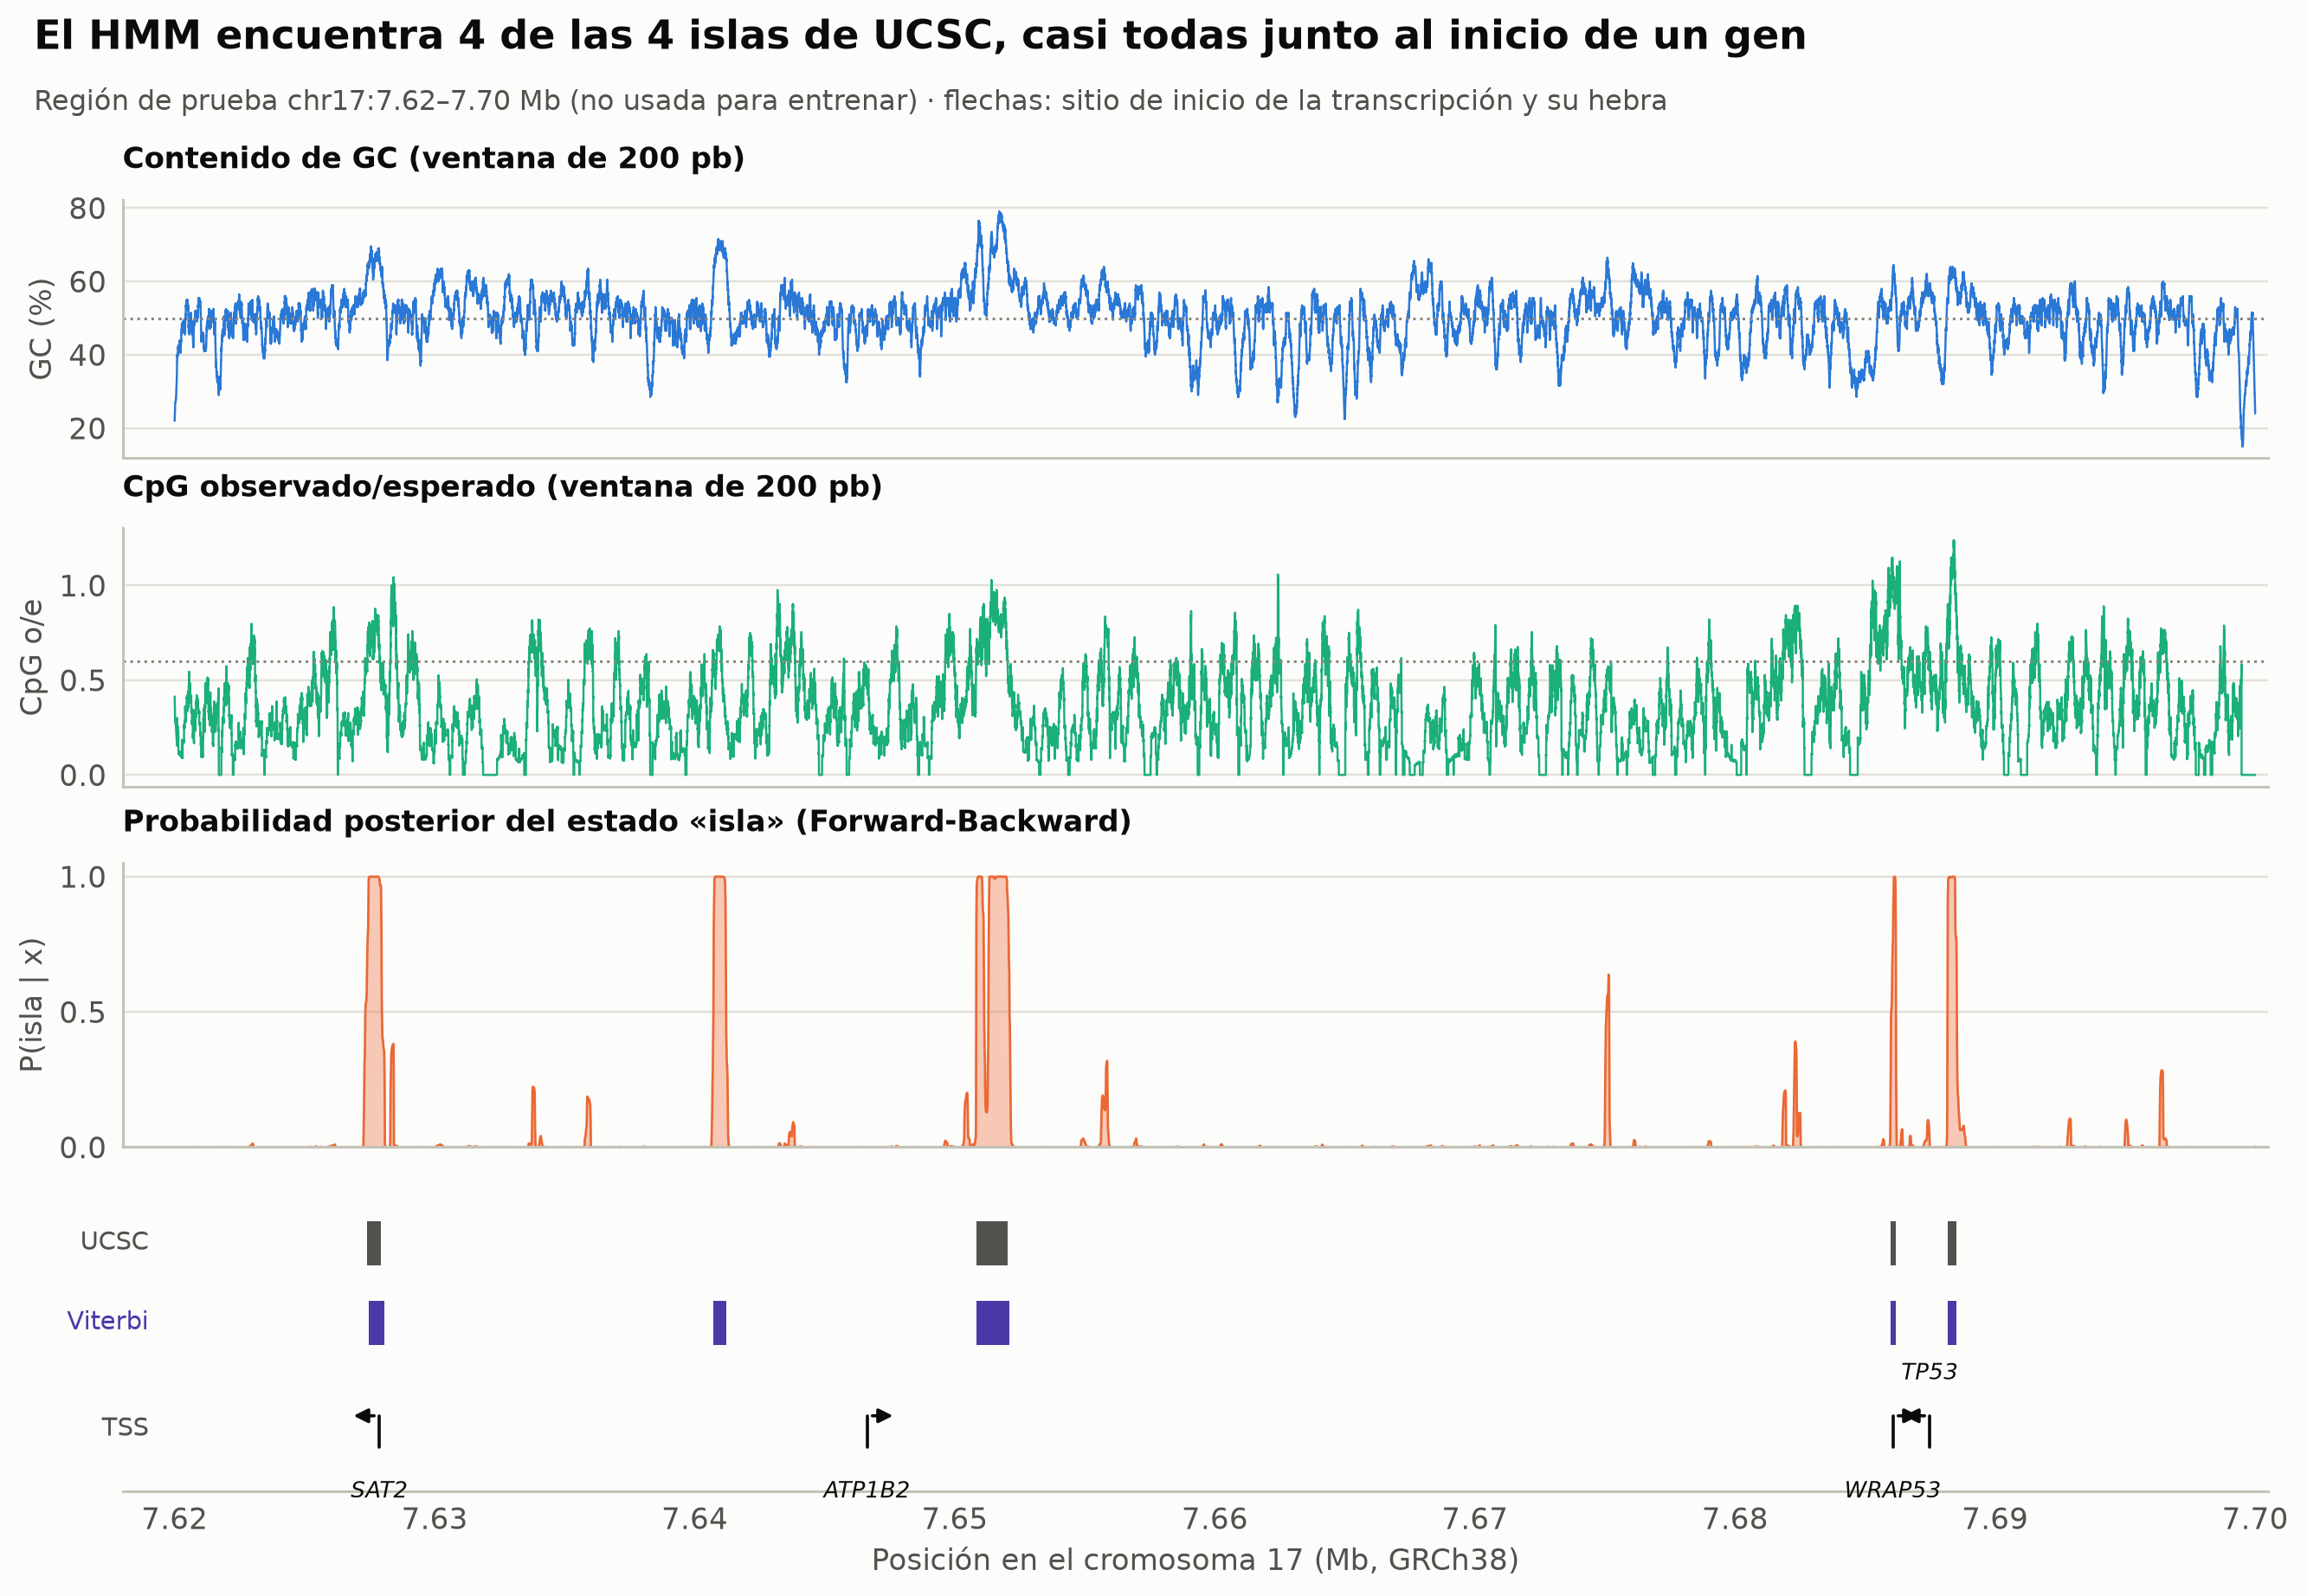

In [20]:
pos_test = np.arange(SPLIT, len(chr17))
win = 200
def rolling_stats(x, w):
    is_c, is_g = (x == 1).astype(float), (x == 2).astype(float)
    is_cg = np.r_[(x[:-1] == 1) & (x[1:] == 2), False].astype(float)
    k = np.ones(w) / w
    fc, fg, fcg = (np.convolve(v, k, mode="same") for v in (is_c, is_g, is_cg))
    return fc + fg, np.where(fc * fg > 0, fcg / np.maximum(fc * fg, 1e-9), 0)

gc_w, oe_w = rolling_stats(x_test, win)
mb = (pos_test + OFFSET) / 1e6

fig, axes = plt.subplots(4, 1, figsize=(12, 7.6), sharex=True, height_ratios=[1, 1, 1.1, 1.2])
axes[0].plot(mb, gc_w * 100, color=ec.BLUE, lw=0.8); axes[0].axhline(50, color=ec.MUTED, ls=":", lw=1)
axes[0].set_ylabel("GC (%)"); axes[0].set_title("Contenido de GC (ventana de 200 pb)", fontsize=11, loc="left")
axes[1].plot(mb, oe_w, color=ec.AQUA, lw=0.8); axes[1].axhline(0.6, color=ec.MUTED, ls=":", lw=1)
axes[1].set_ylabel("CpG o/e"); axes[1].set_title("CpG observado/esperado (ventana de 200 pb)", fontsize=11, loc="left")
axes[2].fill_between(mb, cpg_post[:, 1], color=ec.ORANGE, alpha=0.35, lw=0)
axes[2].plot(mb, cpg_post[:, 1], color=ec.ORANGE, lw=0.9)
axes[2].set_ylim(0, 1.05); axes[2].set_ylabel("P(isla | x)")
axes[2].set_title("Probabilidad posterior del estado «isla» (Forward-Backward)", fontsize=11, loc="left")
ax = axes[3]; ax.set_ylim(-0.3, 3.2); ax.set_yticks([]); ax.grid(False); ax.spines["left"].set_visible(False)
for s, e in zip(test_isl.start, test_isl.end):
    ax.add_patch(Rectangle(((s + OFFSET) / 1e6, 2.25), (e - s) / 1e6, 0.5, fc=ec.INK_2, lw=0))
for s, e in segments(cpg_vit):
    ax.add_patch(Rectangle(((s + SPLIT + OFFSET) / 1e6, 1.35), (e - s) / 1e6, 0.5, fc=ec.VIOLET, lw=0))
ax.text(mb[0] - 0.001, 2.5, "UCSC", ha="right", va="center", fontsize=9.5, color=ec.INK_2)
ax.text(mb[0] - 0.001, 1.6, "Viterbi", ha="right", va="center", fontsize=9.5, color=ec.VIOLET)
t_test = tss[tss.tss >= SPLIT]
last = -1
for _, g in t_test.iterrows():
    xg = (g.tss + OFFSET) / 1e6
    ax.annotate("", (xg + (0.0012 if g.strand == "+" else -0.0012), 0.55), (xg, 0.55),
                arrowprops=dict(arrowstyle="-|>", color=ec.INK, lw=1.2))
    ax.plot([xg, xg], [0.2, 0.55], color=ec.INK, lw=1.2)
    lvl = 0.9 if xg - last < 0.004 else 0.02
    ax.text(xg, lvl - 0.2 if lvl < 0.5 else lvl, g.gene, ha="center", va="top" if lvl < 0.5 else "bottom",
            fontsize=8.5, style="italic", color=ec.INK)
    last = xg
ax.text(mb[0] - 0.001, 0.4, "TSS", ha="right", va="center", fontsize=9.5, color=ec.INK_2)
ax.set_xlabel("Posición en el cromosoma 17 (Mb, GRCh38)")
axes[0].set_xlim(mb[0] - 0.002, mb[-1] + 0.0005)
ec.fig_title(fig, f"El HMM encuentra {sum(found)} de las {len(test_isl)} islas de UCSC, casi todas junto al inicio de un gen",
             "Región de prueba chr17:7.62–7.70 Mb (no usada para entrenar) · flechas: sitio de inicio de la transcripción y su hebra")
plt.show()

> 🔎 **Qué observamos.** Donde la posterior sube a 1, también suben el GC y el cociente CpG o/e, y casi siempre hay un
> **sitio de inicio de transcripción** (TSS) cerca: las islas CpG marcan promotores (la columna `dist_TSS` de la
> tabla da la distancia al TSS más cercano, contando los alternativos). Alrededor de 7.687 Mb, donde *TP53* (hebra −)
> y *WRAP53* (hebra +) empiezan en direcciones opuestas, el HMM y UCSC coinciden en dos islas cortas que flanquean
> esos inicios.
>
> Mire ahora la tabla de segmentos: hay **un segmento predicho que no está en UCSC**, de unos 470 pb cerca de
> 7.641 Mb. Tiene 69 % de GC, pero su cociente CpG o/e es 0.58, **justo por debajo** del umbral de 0.6 que UCSC exige.
> UCSC aplica filtros duros; el HMM decide con la **evidencia acumulada** base a base. No hay una "verdad absoluta":
> son dos definiciones operativas distintas de "isla". Contraste siempre sus predicciones con más de una fuente.

### Explorador interactivo de la posterior

Pase el cursor por la curva: verá la posición exacta en el cromosoma, la probabilidad de isla, el GC local y las
bases alrededor (en mayúscula los CpG). Use el deslizador inferior para acercarse a un promotor. Los rectángulos
grises son las islas de UCSC.

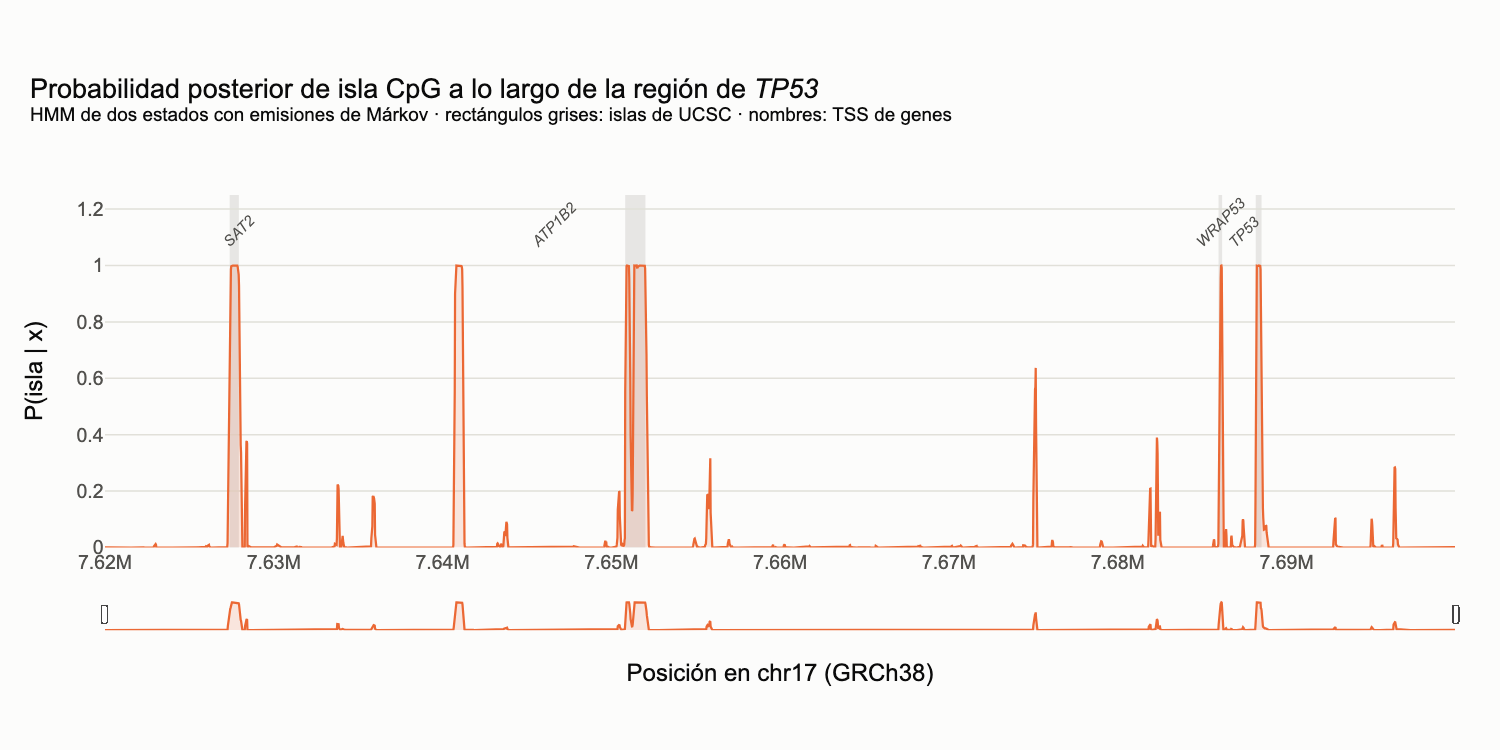

In [21]:
step = 20                                                # un punto cada 20 pb: el gráfico sigue siendo ligero
idx = np.arange(0, len(x_test), step)
def context(i, w=8):
    s = chr17[SPLIT + max(i - w, 0): SPLIT + i + w + 1].lower()
    return s.replace("cg", "CG")
hover_ctx = [context(i) for i in idx]
fig = go.Figure()
for s, e in zip(test_isl.start, test_isl.end):
    fig.add_vrect(x0=s + OFFSET, x1=e + OFFSET, fillcolor=ec.MUTED, opacity=0.18, line_width=0, layer="below")
fig.add_scatter(x=pos_test[idx] + OFFSET + 1, y=cpg_post[idx, 1], mode="lines", name="P(isla | x)",
                line=dict(color=ec.ORANGE, width=1.5), fill="tozeroy", fillcolor="rgba(235,104,52,0.15)",
                customdata=np.stack([gc_w[idx] * 100, hover_ctx, cpg_vit[idx]], axis=-1),
                hovertemplate=("chr17:%{x:,}<br>P(isla) = <b>%{y:.3f}</b><br>GC local = %{customdata[0]:.0f} %"
                               "<br>Viterbi: %{customdata[2]} (1 = isla)<br><span style='font-family:monospace'>%{customdata[1]}</span>"
                               "<extra></extra>"))
for _, g in t_test.iterrows():
    fig.add_annotation(x=g.tss + OFFSET, y=1.04, text=f"<i>{g.gene}</i>", showarrow=False, yanchor="bottom",
                       font=dict(size=10, color=ec.INK_2), textangle=-45)
fig.update_layout(
    title=dict(text="Probabilidad posterior de isla CpG a lo largo de la región de <i>TP53</i><br>"
                    "<sup>HMM de dos estados con emisiones de Márkov · rectángulos grises: islas de UCSC · nombres: TSS de genes</sup>"),
    xaxis=dict(title="Posición en chr17 (GRCh38)", rangeslider=dict(visible=True, thickness=0.08)),
    yaxis=dict(title="P(isla | x)", range=[0, 1.25]), height=500, margin=dict(t=130, l=70, r=30),
    showlegend=False)
fig.show()

✅ **Compruebe su comprensión.** Si duplicara $\bar{\ell}_+$ (islas esperadas más largas), ¿qué le pasaría a los
bordes de los segmentos de Viterbi? ¿Y si hiciera $a_{-+}$ diez veces mayor? Pruébelo cambiando `A_cpg` y
volviendo a ejecutar. (Pista: $a_{-+}$ mayor = entrar a una isla es "barato" → aparecen islas cortas espurias.)

## 8. HMM de perfil: Match, Insert y Delete

En la Lección 4.2 resumimos una familia de secuencias con una **matriz de posición** (PSSM): una columna de
probabilidades por cada posición del motivo. Su gran limitación es que **no admite huecos**: si un miembro de la
familia tiene un aminoácido extra, o le falta uno, la PSSM se descuadra.

Anders Krogh, David Haussler y colaboradores (1994) propusieron la solución: convertir cada columna del alineamiento
múltiple en un **nodo** de un HMM con tres estados:

* **Match $M_k$**: la posición $k$ de la familia está presente; emite un residuo con las probabilidades de esa columna
  (es la columna de la PSSM).
* **Insert $I_k$**: residuos **extra** que esta secuencia tiene entre las posiciones $k$ y $k+1$; emite con las
  frecuencias de fondo y puede repetirse (bucle sobre sí mismo).
* **Delete $D_k$**: la posición $k$ **falta** en esta secuencia; es un estado **silencioso** (no emite nada) que
  permite saltar columnas.

Es como una ruta de autobús con paradas fijas (los estados Match): cada pasajero (secuencia) puede quedarse más tiempo
entre dos paradas (Insert) o saltarse alguna (Delete). Las probabilidades de transición dicen **dónde** son frecuentes
las inserciones y deleciones: en un bucle superficial de la proteína son baratas; en el sitio activo, carísimas.
Una PSSM no puede expresar eso; un HMM de perfil, sí.

### Construirlo a partir de un alineamiento múltiple

Usaremos un alineamiento de juguete de 7 secuencias inspirado en el motivo **Walker A** (`GxxxxGK[ST]`), el
"lazo P" que une el fosfato del ATP en muchísimas proteínas:

```
s1  G A E - G S G K S T
s2  G A E - G S G K T T
s3  G P E - G A G K S T
s4  G P E R G A G K S T
s5  G S - - G S G K S T
s6  G A E - G C G K S T
s7  G P D K G A G K S T
```

**Regla de las columnas:** una columna con residuos en al menos la mitad de las secuencias es una columna **Match**;
si no, es de **Inserción**. La columna 4 tiene residuos sólo en 2 de 7 secuencias → es inserción. Quedan **9 columnas
Match** ($M_1 \dots M_9$).

**Emisiones con pseudocuentas (ejemplo a mano, $M_3$).** La columna 3 tiene E, E, E, E, –, E, D: cinco E, una D y un
hueco (el hueco no emite: esa secuencia pasa por $D_3$). Con una pseudocuenta de 1 para cada uno de los 20
aminoácidos:

$$
e_{M_3}(\text{E}) = \frac{5 + 1}{6 + 20} = 0.23 \qquad
e_{M_3}(\text{D}) = \frac{1 + 1}{26} = 0.077 \qquad
e_{M_3}(\text{otro}) = \frac{1}{26} = 0.038
$$

**Transiciones (ejemplo a mano, desde $M_3$).** De las 6 secuencias que pasan por $M_3$, cuatro van directo a $M_4$
y dos (s4 y s7) entran en $I_3$. Con pseudocuenta 1 en las tres salidas posibles:
$a_{M_3M_4} = 5/9$, $a_{M_3I_3} = 3/9$, $a_{M_3D_4} = 1/9$.

Para alinear una secuencia nueva al perfil se usa Viterbi con **puntajes log-odds** frente a un modelo de fondo $q$
(Durbin *et al.*, ecuación 5.19):

$$
V^M_j(i) = \log\frac{e_{M_j}(x_i)}{q_{x_i}} + \max\begin{cases} V^M_{j-1}(i-1) + \log a_{M_{j-1}M_j}\\
V^I_{j-1}(i-1) + \log a_{I_{j-1}M_j}\\ V^D_{j-1}(i-1) + \log a_{D_{j-1}M_j}\end{cases}
\qquad
V^I_j(i) = \max\begin{cases} V^M_j(i-1) + \log a_{M_jI_j}\\ V^I_j(i-1) + \log a_{I_jI_j}\\ V^D_j(i-1) + \log a_{D_jI_j}\end{cases}
$$

$$
V^D_j(i) = \max\big\{\, V^M_{j-1}(i) + \log a_{M_{j-1}D_j},\ V^I_{j-1}(i) + \log a_{I_{j-1}D_j},\ V^D_{j-1}(i) + \log a_{D_{j-1}D_j} \,\big\}
$$

| Símbolo | Significado |
|---|---|
| $V^M_j(i),\ V^I_j(i),\ V^D_j(i)$ | mejor puntaje que alinea $x_1 \dots x_i$ al modelo terminando en $M_j$, $I_j$ o $D_j$ |
| $e_{M_j}(a)$ | probabilidad de que la columna $j$ tenga el aminoácido $a$ |
| $q_a$ | frecuencia de fondo del aminoácido $a$ (aquí uniforme, $1/20$); los Insert emiten con $q$, así que su log-odds es 0 |
| $a_{XY}$ | transiciones entre estados del perfil |

Observe que $V^D$ **no avanza** en la secuencia ($i$ no cambia): el estado Delete no consume residuos. Es
Needleman-Wunsch otra vez, pero con costos de hueco y de sustitución **distintos en cada posición** de la familia.

In [22]:
AA20 = "ACDEFGHIKLMNPQRSTVWY"
toy_msa = ["GAE-GSGKST", "GAE-GSGKTT", "GPE-GAGKST", "GPERGAGKST", "GS--GSGKST", "GAE-GCGKST", "GPDKGAGKST"]
MI, II, DI = 0, 1, 2                                  # índices de tipo de estado: Match, Insert, Delete

def build_profile_hmm(msa, alphabet=AA20, threshold=0.5, pseudo=1.0):
    """HMM de perfil a partir de un alineamiento múltiple (regla del 50 % para las columnas Match)."""
    n_seq, n_col = len(msa), len(msa[0])
    match_cols = [j for j in range(n_col) if sum(s[j] != "-" for s in msa) >= threshold * n_seq]
    L = len(match_cols)
    e_cnt = np.full((L + 1, len(alphabet)), pseudo)  # fila 0 sin uso (M0 = inicio)
    t_cnt = np.full((L + 1, 3, 3), pseudo)           # t[k, desde, hacia]: hacia M/D = nodo k+1, hacia I = I_k
    t_cnt[L, :, DI] = 0                              # desde el último nodo no se puede ir a un Delete
    t_cnt[0, DI, :] = 0                              # D0 no existe
    for s in msa:
        path, k = [(MI, 0)], 0
        for j, c in enumerate(s):
            if j in match_cols:
                k += 1
                path.append((MI, k) if c != "-" else (DI, k))
                if c != "-":
                    e_cnt[k, alphabet.index(c)] += 1
            elif c != "-":
                path.append((II, k))
        path.append((MI, L + 1))                     # fin
        for (a, ka), (b, _) in zip(path[:-1], path[1:]):
            t_cnt[ka, a, b] += 1
    e_M = e_cnt / e_cnt.sum(1, keepdims=True)
    with np.errstate(divide="ignore", invalid="ignore"):
        t = t_cnt / t_cnt.sum(2, keepdims=True)
    return dict(L=L, match_cols=match_cols, e_M=e_M, t=np.nan_to_num(t), e_cnt=e_cnt, t_cnt=t_cnt)

prof = build_profile_hmm(toy_msa)
print("Columnas Match del alineamiento:", [j + 1 for j in prof["match_cols"]], "→ L =", prof["L"])
print(f"e_M3(E) = {prof['e_M'][3, AA20.index('E')]:.3f} · e_M3(D) = {prof['e_M'][3, AA20.index('D')]:.3f}")
print("Transiciones desde M3 (→M4, →I3, →D4):", prof["t"][3, MI].round(3))
consensus = "".join(AA20[prof["e_M"][k].argmax()] for k in range(1, prof["L"] + 1))
print("Consenso del perfil:", consensus)

Columnas Match del alineamiento: [1, 2, 3, 5, 6, 7, 8, 9, 10] → L = 9
e_M3(E) = 0.231 · e_M3(D) = 0.077
Transiciones desde M3 (→M4, →I3, →D4): [0.556 0.333 0.111]
Consenso del perfil: GAEGAGKST


In [23]:
def profile_viterbi(prof, seq, alphabet=AA20):
    """Alineamiento global de seq a un HMM de perfil (log-odds frente a un fondo uniforme)."""
    L, n = prof["L"], len(seq)
    with np.errstate(divide="ignore"):
        lt = np.log(prof["t"])
        lem = np.log(prof["e_M"] * len(alphabet))    # log(e / q) con q = 1/20
    x = [alphabet.index(c) for c in seq]
    V = np.full((3, L + 1, n + 1), -np.inf); P = np.zeros((3, L + 1, n + 1), dtype=int)
    V[MI, 0, 0] = 0.0
    for i in range(n + 1):
        for j in range(L + 1):
            if j >= 1 and i >= 1:
                c = V[:, j - 1, i - 1] + lt[j - 1, :, MI]
                P[MI, j, i] = c.argmax(); V[MI, j, i] = lem[j, x[i - 1]] + c.max()
            if i >= 1:
                c = V[:, j, i - 1] + lt[j, :, II]
                P[II, j, i] = c.argmax(); V[II, j, i] = c.max()
            if j >= 1:
                c = V[:, j - 1, i] + lt[j - 1, :, DI]
                P[DI, j, i] = c.argmax(); V[DI, j, i] = c.max()
    end = V[:, L, n] + lt[L, :, MI]
    state, j, i = int(end.argmax()), L, n
    path = []
    while not (state == MI and j == 0 and i == 0):
        path.append((state, j, i))
        prev = P[state, j, i]
        if state == MI:   j, i = j - 1, i - 1
        elif state == II: i = i - 1
        else:             j = j - 1
        state = prev
    return path[::-1], end.max()

def show_alignment(path, seq):
    top, bot, states = "", "", []
    for s, j, i in path:
        if s == MI:
            top += consensus[j - 1]; bot += seq[i - 1]; states.append(f"M{j}")
        elif s == II:
            top += "."; bot += seq[i - 1].lower(); states.append(f"I{j}")
        else:
            top += consensus[j - 1]; bot += "-"; states.append(f"D{j}")
    return top, bot, states

queries_toy = {"con inserción": "GPEKDGAGKST", "con deleción": "GAGSGKST", "no relacionada": "WLHWMYRQNF"}
toy_paths = {}
for name, q in queries_toy.items():
    path, score = profile_viterbi(prof, q)
    top, bot, states = show_alignment(path, q)
    toy_paths[name] = path
    print(f"{name:>15}: log-odds = {score:6.2f} nats")
    print(f"{'perfil':>15}  {top}\n{'secuencia':>15}  {bot}\n{'estados':>15}  {' '.join(states)}\n")

  con inserción: log-odds =   8.99 nats
         perfil  GAE..GAGKST
      secuencia  GPEkdGAGKST
        estados  M1 M2 M3 I3 I3 M4 M5 M6 M7 M8 M9

   con deleción: log-odds =   8.73 nats
         perfil  GAEGAGKST
      secuencia  GA-GSGKST
        estados  M1 M2 D3 M4 M5 M6 M7 M8 M9

 no relacionada: log-odds =  -6.31 nats
         perfil  GAE.GAGKST
      secuencia  WLHwMYRQNF
        estados  M1 M2 M3 I3 M4 M5 M6 M7 M8 M9



> 🔎 **Qué observamos.** La secuencia con dos residuos extra (`KD`) los aloja en el estado $I_3$ (en minúscula, como
> los muestra HMMER); la que perdió la E pasa por el estado silencioso $D_3$. Ambas tienen un puntaje log-odds
> **positivo**: se parecen más a la familia que al azar. La secuencia no relacionada tiene un puntaje muy negativo.
> En el diagrama siguiente, el camino de la secuencia con inserción está resaltado en naranja.

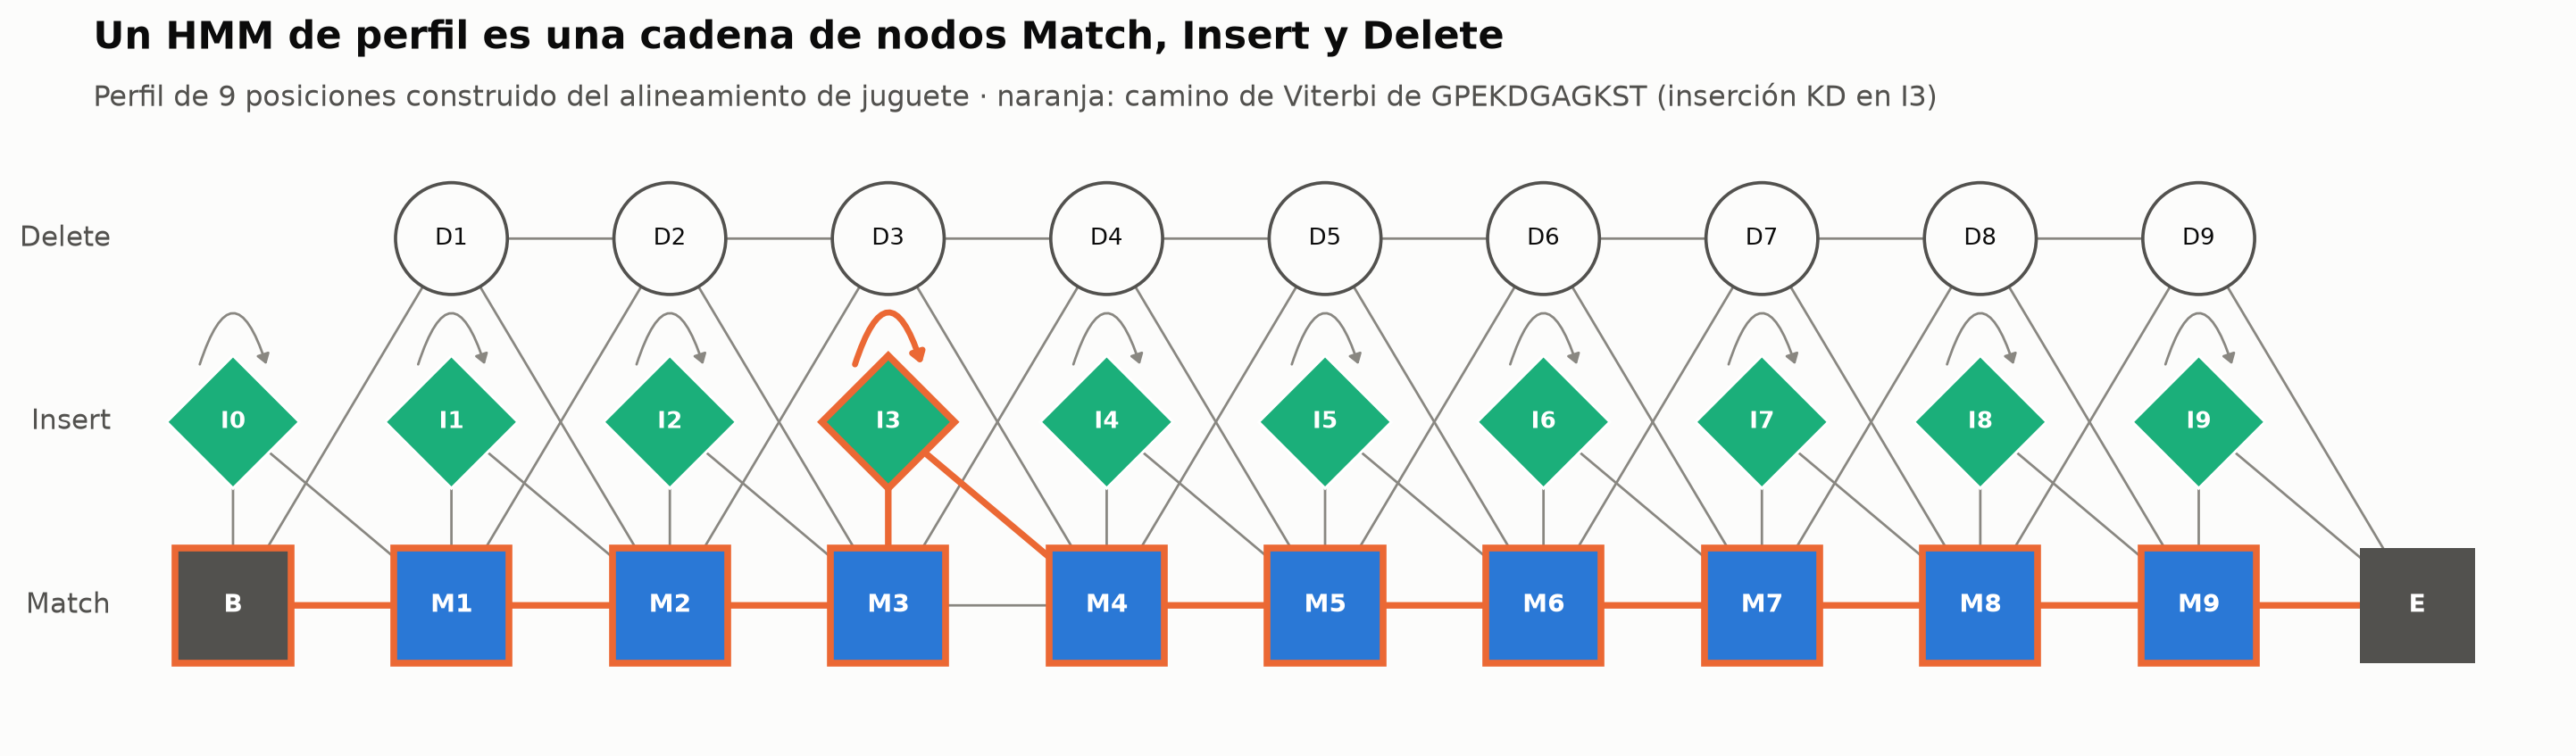

In [24]:
def draw_profile_hmm(ax, L, path=None):
    """Arquitectura de un HMM de perfil: Match (cuadrados), Insert (rombos), Delete (círculos)."""
    X = lambda k: 1.25 * k
    yM, yI, yD = 0.0, 1.05, 2.1
    ax.set_xlim(-0.8, X(L + 1) + 0.8); ax.set_ylim(-0.75, 2.75); ax.set_aspect("equal"); ax.axis("off")
    used = set()
    if path:
        full = [(MI, 0, 0)] + path + [(MI, L + 1, None)]
        used = {((a, ja), (b, jb)) for (a, ja, _), (b, jb, _) in zip(full[:-1], full[1:])}
        visited = {(a, ja) for a, ja, _ in full}
    else:
        visited = set()
    pos = lambda s, k: (X(k), {MI: yM, II: yI, DI: yD}[s])
    def edge(a, b, rad=0.0):
        on = (a, b) in used
        p, q = pos(*a), pos(*b)
        ax.add_patch(FancyArrowPatch(p, q, connectionstyle=f"arc3,rad={rad}", shrinkA=13, shrinkB=13,
                                     arrowstyle="-|>,head_length=4,head_width=2.5", lw=2.4 if on else 0.9,
                                     color=ec.ORANGE if on else ec.MUTED, zorder=4 if on else 1))
    for k in range(L + 1):
        edge((MI, k), (MI, k + 1)); edge((MI, k), (II, k)); edge((II, k), (MI, k + 1))
        if k < L:
            edge((MI, k), (DI, k + 1))
        if k >= 1:
            edge((DI, k), (MI, k + 1))
            if k < L:
                edge((DI, k), (DI, k + 1))
    for k in range(L + 1):                            # nodos
        on = (MI, k) in visited
        lbl = "B" if k == 0 else f"M{k}"
        ax.add_patch(Rectangle((X(k) - 0.33, yM - 0.33), 0.66, 0.66, fc=ec.BLUE if k else ec.INK_2,
                               ec=ec.ORANGE if on else "white", lw=2.5 if on else 1, zorder=5))
        ax.text(X(k), yM, lbl, ha="center", va="center", color="white", fontsize=9, fontweight="bold", zorder=6)
        on = (II, k) in visited
        ax.add_patch(RegularPolygon((X(k), yI), 4, radius=0.38, fc=ec.AQUA, ec=ec.ORANGE if on else "white",
                                    lw=2.5 if on else 1, zorder=5))
        ax.text(X(k), yI, f"I{k}", ha="center", va="center", color="white", fontsize=8.5, fontweight="bold", zorder=6)
        # bucle del Insert sobre sí mismo
        loop_on = ((II, k), (II, k)) in used
        ax.add_patch(FancyArrowPatch((X(k) - 0.2, yI + 0.3), (X(k) + 0.2, yI + 0.3), connectionstyle="arc3,rad=-1.6",
                                     arrowstyle="-|>,head_length=3,head_width=2", lw=2.2 if loop_on else 0.9,
                                     color=ec.ORANGE if loop_on else ec.MUTED, zorder=1))
        if k >= 1:
            on = (DI, k) in visited
            ax.add_patch(Circle((X(k), yD), 0.32, fc=ec.SURFACE, ec=ec.ORANGE if on else ec.INK_2,
                                lw=2.5 if on else 1.2, zorder=5))
            ax.text(X(k), yD, f"D{k}", ha="center", va="center", color=ec.INK, fontsize=8.5, zorder=6)
    ax.add_patch(Rectangle((X(L + 1) - 0.33, yM - 0.33), 0.66, 0.66, fc=ec.INK_2, ec="white", zorder=5))
    ax.text(X(L + 1), yM, "E", ha="center", va="center", color="white", fontsize=9, fontweight="bold", zorder=6)
    for y, t in [(yM, "Match"), (yI, "Insert"), (yD, "Delete")]:
        ax.text(-0.7, y, t, ha="right", va="center", fontsize=10, color=ec.INK_2)

fig, ax = plt.subplots(figsize=(13, 4.4))
draw_profile_hmm(ax, prof["L"], toy_paths["con inserción"])
ec.title(ax, "Un HMM de perfil es una cadena de nodos Match, Insert y Delete",
         "Perfil de 9 posiciones construido del alineamiento de juguete · naranja: camino de Viterbi de GPEKDGAGKST (inserción KD en I3)")
plt.show()

✅ **Compruebe su comprensión.** ¿Por qué el estado Delete no tiene emisiones? ¿Y por qué, en el diagrama, no hay
flechas de $M_k$ hacia atrás? (Respuesta: Delete representa una posición **ausente**, así que no produce residuos; y
las flechas sólo van hacia adelante porque el orden de las columnas de la familia se conserva: una proteína no
"vuelve" a una posición anterior.)

## 9. De nuestro perfil a Pfam: la familia de los transportadores ABC

**Pfam** (Mistry *et al.*, 2021; hoy integrado en InterPro) es exactamente esto a escala planetaria: unas 20 000
familias de dominios de proteínas, cada una definida por un **alineamiento semilla** (*seed*) curado a mano y un HMM
de perfil construido con HMMER a partir de él. Ese HMM se usa luego para encontrar a **todos** los miembros de la
familia en UniProt.

Descarguemos la semilla de la familia **PF00005, ABC_tran** (el dominio de unión a ATP de los transportadores ABC),
en formato Stockholm, y apliquemos nuestra regla del 50 %.

In [25]:
pfam_raw = course_bytes("PF00005_seed.sto.gz",
                        "https://www.ebi.ac.uk/interpro/api/entry/pfam/PF00005/?annotation=alignment:seed")
pfam_text = gzip.decompress(pfam_raw).decode() if pfam_raw[:2] == b"\x1f\x8b" else pfam_raw.decode()
seed = AlignIO.read(io.StringIO(pfam_text), "stockholm")
n_seed, n_cols = len(seed), seed.get_alignment_length()
cols = [[str(r.seq[j]).upper() for r in seed if r.seq[j] not in "-."] for j in range(n_cols)]
match_idx = [j for j, c in enumerate(cols) if len(c) >= 0.5 * n_seed]
pf_consensus = "".join(Counter(cols[j]).most_common(1)[0][0] for j in match_idx)

def info_content(residues, pseudo=0.5):
    cnt = np.array([residues.count(a) for a in AA20], dtype=float) + pseudo
    p = cnt / cnt.sum()
    return np.log2(20) + (p * np.log2(p)).sum()     # bits: log2(20) − entropía

ic = np.array([info_content(cols[j]) for j in match_idx])
print(f"Semilla de PF00005: {n_seed} secuencias · {n_cols} columnas · {len(match_idx)} columnas Match")
print("Consenso:", pf_consensus)
print("\nPrimeras secuencias de la semilla:")
for r in seed[:4]:
    print(f"  {r.id:<22} {str(r.seq)[:70]}")

Semilla de PF00005: 55 secuencias · 274 columnas · 150 columnas Match
Consenso: LKNVSLTLPPGEVVALVGPNGAGKSTLLKLISGLLQPTEGTILIDGRDLTDDERRSLRKRIGYVFQDPHLFPRLTVRENLRLGLLLFGLSKAEADARAEEALERLGLGDLADRRVGESPGTLSGGQRQRVAIARALLTKPKVLLLDEPTA

Primeras secuencias de la semilla:
  ARAG_ECOLI/23-172      LTDISFDCYAGQVHALMGENGAGKSTLLKILSGNYAP-----TTGSV---------------------VI
  YTFR_ECOLI/25-174      LDNVDFSLRRGEIMALLGENGAGKSTLIKALTGVYHA-----DRGTI---------------------WL
  THIQ_ECOLI/15-158      PMRFSLTVERGEQVAILGPSGAGKSTLLNLIAGFLTP-----ASGSL---------------------TI
  MODC_ECOLI/14-157      CLTINETLPANGITAIFGVSGAGKTSLINAISGLTRP-----QKGRI---------------------VL


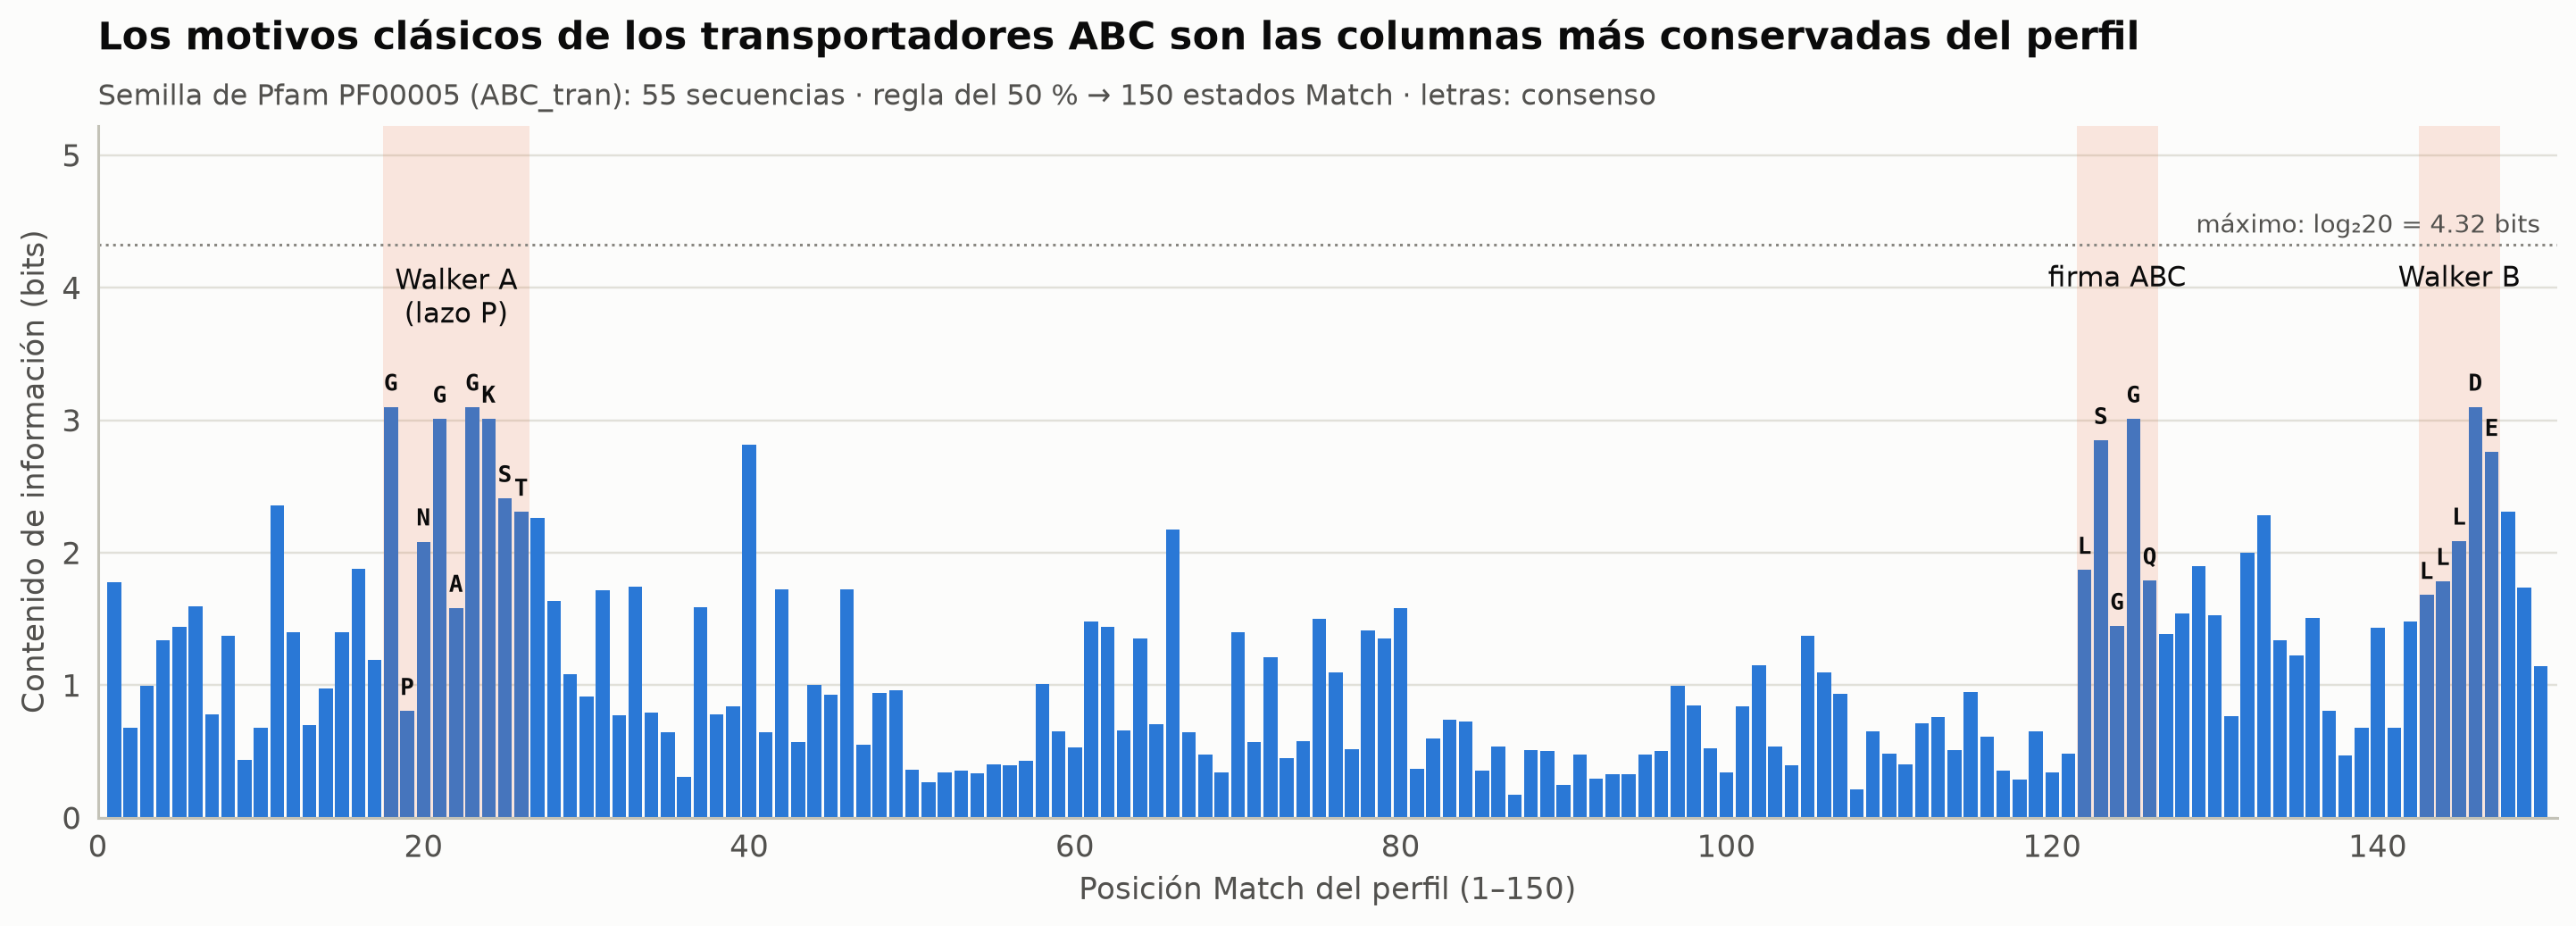

In [26]:
motifs = {"Walker A\n(lazo P)": "GPNGAGKST", "firma ABC": "LSGGQ", "Walker B": "LLLDE"}
fig, ax = plt.subplots(figsize=(13, 4.6))
ax.bar(np.arange(1, len(ic) + 1), ic, color=ec.BLUE, width=0.85)
ax.set_xlim(0, len(ic) + 1); ax.set_ylim(0, np.log2(20) + 0.9)
ax.axhline(np.log2(20), color=ec.MUTED, ls=":", lw=1)
ax.text(len(ic), np.log2(20) + 0.05, "máximo: log₂20 = 4.32 bits", ha="right", va="bottom", fontsize=9, color=ec.INK_2)
for name, m in motifs.items():
    s = pf_consensus.find(m)
    if s < 0:
        continue
    ax.axvspan(s + 0.5, s + len(m) + 0.5, color=ec.ORANGE, alpha=0.15, lw=0)
    for k, a in enumerate(m):
        ax.text(s + k + 1, ic[s + k] + 0.08, a, ha="center", va="bottom", fontsize=8.5, family="DejaVu Sans Mono",
                color=ec.INK, fontweight="bold")
    ax.text(s + len(m) / 2 + 0.5, np.log2(20) - 0.15, name, ha="center", va="top", fontsize=10, color=ec.INK)
ax.set_xlabel("Posición Match del perfil (1–%d)" % len(ic)); ax.set_ylabel("Contenido de información (bits)")
ec.title(ax, "Los motivos clásicos de los transportadores ABC son las columnas más conservadas del perfil",
         f"Semilla de Pfam PF00005 (ABC_tran): {n_seed} secuencias · regla del 50 % → {len(ic)} estados Match · letras: consenso")
plt.show()

> 🔎 **Qué observamos.** Sin decirle nada de bioquímica, el perfil "descubre" las tres regiones que definen a la
> familia: el **Walker A** (`GxxGxGKST`, que abraza los fosfatos del ATP), la **firma ABC** (`LSGGQ`, exclusiva de esta
> familia) y el **Walker B** (`hhhhDE`, que coordina el magnesio). Entre ellas, las columnas con poca información son
> bucles e hélices superficiales, donde el HMM de perfil tolerará sustituciones e inserciones con facilidad.
> Nuestra regla del 50 % da el mismo número de columnas Match que usa HMMER para esta familia.

## 10. 🧪 HMMER de verdad (en Colab)

**HMMER** (Eddy 1998, 2011) es el programa que usa Pfam. Sus dos órdenes básicas:

| Orden | Qué hace |
|---|---|
| `hmmbuild familia.hmm semilla.sto` | construye el HMM de perfil a partir del alineamiento (con pseudocuentas más finas que las nuestras: mezclas de Dirichlet) |
| `hmmsearch familia.hmm proteoma.fasta` | busca la familia en una base de datos de secuencias, con E-values como los de BLAST |
| `phmmer consulta.fasta proteoma.fasta` | búsqueda con **una sola** secuencia (como BLASTP, pero con la maquinaria de HMMER) |

HMMER3 usa un modelo de perfil llamado *Plan7* (sin transiciones Delete↔Insert) y un filtro muy rápido (MSV) antes
de aplicar Forward, por lo que es tan rápido como BLAST. Y aquí está la clave: sus puntajes se basan en **Forward**
(suma sobre todos los alineamientos), no sólo en el mejor alineamiento, lo que lo hace más sensible.

Vamos a buscar la familia ABC_tran en las ~500 proteínas de *Mycoplasma genitalium* (Lección 3.4), y a comparar
con una búsqueda de **una sola** secuencia de la semilla.

In [27]:
if shutil.which("hmmsearch") is None and IN_COLAB:
    !apt-get -qq install -y hmmer > /dev/null
HAS_HMMER = shutil.which("hmmsearch") is not None
print("HMMER disponible:", HAS_HMMER)
if HAS_HMMER:
    print(subprocess.run(["hmmsearch", "-h"], capture_output=True, text=True).stdout.splitlines()[1])
else:
    print("⚠️ Ejecute este notebook en Colab para usar HMMER (aquí se omite esta sección).")

# Proteoma de M. genitalium (CDS anotados en su GenBank), como en la Lección 3.4
genome = SeqIO.read(io.StringIO(course_bytes("NC_000908.2.gb").decode()), "genbank")
proteome = [(f.qualifiers.get("locus_tag", ["?"])[0], f.qualifiers.get("product", [""])[0],
             f.qualifiers["translation"][0])
            for f in genome.features if f.type == "CDS" and "translation" in f.qualifiers]
products = {tag: prod for tag, prod, _ in proteome}
print(f"Proteoma de M. genitalium: {len(proteome)} proteínas")

HMMER disponible: False
⚠️ Ejecute este notebook en Colab para usar HMMER (aquí se omite esta sección).
Proteoma de M. genitalium: 504 proteínas


In [28]:
def read_tblout(path):
    """Lee la tabla --tblout de HMMER (columnas separadas por espacios; la descripción puede tener espacios)."""
    rows = []
    for line in open(path):
        if line.startswith("#"):
            continue
        f = line.rstrip("\n").split(maxsplit=18)
        rows.append(dict(target=f[0], evalue=float(f[4]), score=float(f[5]), bias=float(f[6])))
    return pd.DataFrame(rows)

if HAS_HMMER:
    with open("seed_PF00005.sto", "w") as fh:
        fh.write(pfam_text)
    with open("mgen_proteome.fasta", "w") as fh:
        for tag, prod, seq in proteome:
            fh.write(f">{tag} {prod}\n{seq}\n")
    single = seed[0]                                    # una sola secuencia de la semilla, sin huecos
    with open("single_query.fasta", "w") as fh:
        fh.write(f">{single.id}\n{str(single.seq).replace('-', '').replace('.', '').upper()}\n")

    subprocess.run(["hmmbuild", "ABC_tran.hmm", "seed_PF00005.sto"], check=True, capture_output=True)
    subprocess.run(["hmmsearch", "--tblout", "hmm_hits.tbl", "--noali", "-E", "10",
                    "ABC_tran.hmm", "mgen_proteome.fasta"], check=True, capture_output=True)
    subprocess.run(["phmmer", "--tblout", "single_hits.tbl", "--noali", "-E", "10",
                    "single_query.fasta", "mgen_proteome.fasta"], check=True, capture_output=True)
    print(open("ABC_tran.hmm").read().split("HMM ")[0][:420])      # cabecera del modelo
    hmm_hits, single_hits = read_tblout("hmm_hits.tbl"), read_tblout("single_hits.tbl")
    hmm_hits["producto"] = hmm_hits.target.map(products)
    print(f"hmmsearch (perfil): {(hmm_hits.evalue < 0.01).sum()} proteínas con E < 0.01")
    print(f"phmmer (una secuencia, {single.id}): {(single_hits.evalue < 0.01).sum()} proteínas con E < 0.01")
    display(hmm_hits.head(25)[["target", "producto", "score", "evalue"]])

In [29]:
if HAS_HMMER:
    both = hmm_hits.merge(single_hits[["target", "evalue"]], on="target", how="left", suffixes=("", "_single"))
    both["evalue_single"] = both["evalue_single"].fillna(10)
    is_abc = both.producto.str.contains("ABC|ATP-binding", case=False, regex=True)
    fig, ax = plt.subplots(figsize=(9.5, 5.6))
    sx = (-np.log10(both.evalue_single.clip(lower=1e-80))).clip(lower=0)      # no encontrada (E = 10) → 0
    sy = -np.log10(both.evalue.clip(lower=1e-80))
    for mask, col, lbl in [(is_abc, ec.ORANGE, "producto anotado como ABC / ATP-binding"),
                           (~is_abc, ec.MUTED, "otro producto")]:
        ax.scatter(sx[mask], sy[mask], s=46, color=col, edgecolor=ec.SURFACE, linewidth=1.2, label=lbl, zorder=3)
    top = max(sx.max(), sy.max()) * 1.08
    ax.plot([0, top], [0, top], color=ec.BASELINE, lw=1)
    ax.text(top * 0.97, top * 0.93, "igual confianza", ha="right", va="top", fontsize=9, color=ec.MUTED, rotation=0)
    ax.axhline(2, color=ec.BLUE, lw=1, ls="--"); ax.axvline(2, color=ec.BLUE, lw=1, ls="--")
    ax.text(top, 2.5, "E = 0.01", ha="right", va="bottom", fontsize=9, color=ec.INK_2)
    ax.set_xlim(-2, top); ax.set_ylim(-2, top)
    ax.set_xlabel("−log₁₀ E con UNA secuencia (phmmer) · 0 = no encontrada")
    ax.set_ylabel("−log₁₀ E con el PERFIL (hmmsearch)")
    ax.grid(True, axis="both"); ax.legend(loc="center right", fontsize=9.5)
    ec.title(ax, "El perfil de la familia encuentra transportadores ABC que una sola secuencia no ve",
             "Proteoma de M. genitalium · un punto por proteína hallada por hmmsearch · sobre la diagonal = más confianza con el perfil")
    plt.show()

> 🔎 **Qué observamos (en Colab).** El perfil encuentra unas treinta proteínas con E < 0.01. Las primeras (E-values
> minúsculos) están anotadas como transportadores ABC o proteínas con casete de unión a ATP; más abajo aparecen otras
> **NTPasas de lazo P** (guanilato quinasa, la helicasa RuvB, la proteasa Lon, FtsY…), que comparten el Walker A:
> homología lejana real, aunque no sean transportadores. Una sola secuencia de la semilla (phmmer) recupera sólo
> alrededor de la mitad: los puntos por encima de la diagonal son proteínas que el perfil ve con **mucha** más
> confianza. El perfil "sabe" qué posiciones son intocables (Walker A, firma, Walker B) y
> cuáles pueden variar, así que detecta homólogos lejanos por debajo de la zona crepuscular de la Lección 3.4.

### Opcional: buscar en Pfam completo

Con `hmmscan` se hace la pregunta inversa: *"¿qué dominios de Pfam tiene esta proteína?"*. Requiere descargar
Pfam-A.hmm (~1.5 GB comprimido), así que no lo ejecutamos aquí:

```bash
wget https://ftp.ebi.ac.uk/pub/databases/Pfam/current_release/Pfam-A.hmm.gz && gunzip Pfam-A.hmm.gz
hmmpress Pfam-A.hmm
hmmscan --domtblout dominios.tbl Pfam-A.hmm mgen_proteome.fasta
```

## ✍️ Ejercicios

**Ejercicio 1 — Viterbi a mano.** Con el modelo del casino, llene a mano (con logaritmos naturales) la tabla de
Viterbi para $x = (1, 6, 6)$ y recupere el camino. ¿Es el mismo que para $(6, 6, 1)$? Compruébelo con `viterbi`.

**Ejercicio 2 — Un casino más nervioso.** Cambie las transiciones a $a_{FL} = 0.2$, $a_{LF} = 0.3$, vuelva a decodificar
las 300 tiradas (las mismas `rolls`) con Viterbi y cuente cuántos tramos cargados predice. Compare con el modelo
original. ¿Qué modelo explica mejor las tiradas (compare $\log P(x)$ con Forward)?

**Ejercicio 3 — Islas CpG en *E. coli*.** Aplique el HMM de islas CpG (entrenado en humano) a los primeros 80 kb del
genoma de *E. coli* K-12 (`NC_000913.3.fasta.gz`). ¿Qué fracción de la secuencia marca como "isla"? Calcule el CpG
o/e global de *E. coli* y explique el resultado. (Pista: las bacterias no metilan sus CpG como los mamíferos.)

**Ejercicio 4 — La regla del 50 %.** Construya el perfil del alineamiento de juguete con `threshold=0.25`. ¿Cuántas
columnas Match tiene ahora? Alinee de nuevo `GAGSGKST` y `GPEKDGAGKST`: ¿qué cambia en los caminos de estados?

In [30]:
#@title 🔑 Solución — Ejercicio 1 { display-mode: "form" }
x_ex = np.array([1, 6, 6]) - 1
path_ex, V_ex, ptr_ex, best_ex = viterbi(logp0_c, logA_c, logE_c[:, x_ex].T)
print("V (filas = tiradas 1, 6, 6; columnas F, L):\n", V_ex.round(3))
print("Predecesores (F=0, L=1):\n", ptr_ex)
print("Camino:", "".join(STATES[k] for k in path_ex), f"· P = {np.exp(best_ex):.6f}")
print("V1: F = ln(0.5·1/6) = -2.485 ; L = ln(0.5·0.1) = -2.996 → en la primera columna gana el dado justo,")
print("pero el camino óptimo completo vuelve a ser LLL: explicar un 1 aislado con el dado cargado (e = 0.1) cuesta")
print("menos que pagar un cambio de dado. Cambian los valores intermedios de V, no el camino.")

V (filas = tiradas 1, 6, 6; columnas F, L):
 [[-2.485 -2.996]
 [-4.328 -3.794]
 [-6.171 -4.593]]
Predecesores (F=0, L=1):
 [[0 0]
 [0 1]
 [0 1]]
Camino: LLL · P = 0.010125
V1: F = ln(0.5·1/6) = -2.485 ; L = ln(0.5·0.1) = -2.996 → en la primera columna gana el dado justo,
pero el camino óptimo completo vuelve a ser LLL: explicar un 1 aislado con el dado cargado (e = 0.1) cuesta
menos que pagar un cambio de dado. Cambian los valores intermedios de V, no el camino.


In [31]:
#@title 🔑 Solución — Ejercicio 2 { display-mode: "form" }
A_nerv = np.array([[0.8, 0.2], [0.3, 0.7]])
for name, A_ in [("original", A_casino), ("nervioso", A_nerv)]:
    p_, *_ = viterbi(logp0_c, np.log(A_), logE_c[:, rolls].T)
    _, lp, *_ = forward_backward(p0_casino, A_, E_casino[:, rolls].T)
    print(f"{name:>9}: {len(segments(p_)):>2} tramos cargados · aciertos {np.mean(p_ == true_states):.0%} · log P(x) = {lp:.2f}")
print("El modelo con las transiciones verdaderas suele tener mayor log P(x): la verosimilitud permite comparar modelos.")

 original:  4 tramos cargados · aciertos 85% · log P(x) = -517.35
 nervioso:  9 tramos cargados · aciertos 83% · log P(x) = -517.85
El modelo con las transiciones verdaderas suele tener mayor log P(x): la verosimilitud permite comparar modelos.


In [32]:
#@title 🔑 Solución — Ejercicio 3 { display-mode: "form" }
eco_text = gzip.decompress(course_bytes("NC_000913.3.fasta.gz")).decode()
eco = "".join(l.strip() for l in eco_text.splitlines()[1:])[:80_000].upper()
x_eco = np.array([BASES.find(b) for b in eco]); x_eco[x_eco < 0] = 0
eco_vit, *_ = viterbi(np.log(p0_cpg), np.log(A_cpg), np.log(cpg_emissions(x_eco)))
nc, ng, ncg = eco.count("C"), eco.count("G"), eco.count("CG")
print(f"E. coli (80 kb): GC = {(nc + ng) / len(eco):.1%} · CpG o/e = {ncg * len(eco) / (nc * ng):.2f}")
print(f"Fracción marcada como 'isla': {eco_vit.mean():.1%}   (en la región humana de prueba: {cpg_vit.mean():.1%})")
print("Sin supresión de CpG (o/e ≈ 1), buena parte del genoma bacteriano 'parece isla' para un modelo entrenado en humano:")
print("un HMM sólo es válido para el tipo de secuencia con que se entrenó.")

E. coli (80 kb): GC = 52.7% · CpG o/e = 1.15
Fracción marcada como 'isla': 42.5%   (en la región humana de prueba: 3.7%)
Sin supresión de CpG (o/e ≈ 1), buena parte del genoma bacteriano 'parece isla' para un modelo entrenado en humano:
un HMM sólo es válido para el tipo de secuencia con que se entrenó.


In [33]:
#@title 🔑 Solución — Ejercicio 4 { display-mode: "form" }
prof25 = build_profile_hmm(toy_msa, threshold=0.25)
print("Columnas Match con threshold=0.25:", [j + 1 for j in prof25["match_cols"]], "→ L =", prof25["L"])
cons25 = "".join(AA20[prof25["e_M"][k].argmax()] for k in range(1, prof25["L"] + 1))
for q in ["GAGSGKST", "GPEKDGAGKST"]:
    path, score = profile_viterbi(prof25, q)
    st = [("M", "I", "D")[s] + str(j) for s, j, _ in path]
    print(f"{q:>12}: {' '.join(st)} · log-odds {score:.2f}")
print("Ahora la columna 4 es un Match (M4): casi todas las secuencias pasan por el Delete D4, y la inserción KD")
print("se reparte entre M4 y un Insert. Con pocas secuencias, el umbral cambia la arquitectura del modelo.")

Columnas Match con threshold=0.25: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10] → L = 10
    GAGSGKST: M1 M2 D3 D4 M5 M6 M7 M8 M9 M10 · log-odds 8.44
 GPEKDGAGKST: M1 M2 M3 M4 I4 M5 M6 M7 M8 M9 M10 · log-odds 9.00
Ahora la columna 4 es un Match (M4): casi todas las secuencias pasan por el Delete D4, y la inserción KD
se reparte entre M4 y un Insert. Con pocas secuencias, el umbral cambia la arquitectura del modelo.


## 📌 Resumen

* Una **cadena de Márkov** asigna probabilidades a secuencias con una matriz de transición $a_{st}$, estimada contando
  pares. Dos cadenas (isla / no isla) y un puntaje **log-odds** separan islas CpG del resto del genoma.
* Un **HMM** añade una capa de **estados ocultos** con transiciones $a_{kl}$ y emisiones $e_k(b)$:
  $P(x, \pi) = a_{0\pi_1}\prod e_{\pi_i}(x_i)\,a_{\pi_i\pi_{i+1}}$.
* **Viterbi** (máximo, en log-espacio) da el camino más probable; **Forward** (suma) da $P(x)$; **Forward-Backward**
  da la **posterior** $P(\pi_i = k \mid x)$, la confianza de cada posición. Todos cuestan $O(L K^2)$ en vez de $K^L$.
* Los parámetros se estiman **contando** si conocemos los estados, o con **Baum-Welch** (EM) si no; Baum-Welch sube la
  verosimilitud en cada iteración, pero puede quedar en un máximo local.
* Un HMM de dos estados con emisiones de Márkov, entrenado en 220 kb del cromosoma 17, detectó las islas CpG de UCSC
  en una región no vista, casi siempre junto a un TSS.
* Un **HMM de perfil** convierte un alineamiento múltiple en nodos **Match / Insert / Delete** con costos distintos en
  cada posición. **Pfam** es una colección de estos perfiles; **HMMER** (`hmmbuild`, `hmmsearch`) los construye y
  busca, con más sensibilidad que una búsqueda de una sola secuencia.

## 📚 Para profundizar

* Rabiner, L. R. (1989). A tutorial on hidden Markov models and selected applications in speech recognition.
  *Proceedings of the IEEE* 77(2): 257–286.
* Durbin, R., Eddy, S. R., Krogh, A. & Mitchison, G. (1998). *Biological Sequence Analysis: Probabilistic Models of
  Proteins and Nucleic Acids*. Cambridge University Press. (Capítulos 3 y 5.)
* Krogh, A., Brown, M., Mian, I. S., Sjölander, K. & Haussler, D. (1994). Hidden Markov models in computational
  biology: applications to protein modeling. *Journal of Molecular Biology* 235(5): 1501–1531.
* Eddy, S. R. (1998). Profile hidden Markov models. *Bioinformatics* 14(9): 755–763.
* Eddy, S. R. (2011). Accelerated profile HMM searches. *PLoS Computational Biology* 7(10): e1002195.
* Mistry, J. *et al.* (2021). Pfam: The protein families database in 2021. *Nucleic Acids Research* 49(D1): D412–D419.
* Gardiner-Garden, M. & Frommer, M. (1987). CpG islands in vertebrate genomes. *Journal of Molecular Biology* 196(2):
  261–282.

---

<sub>**Bioinformática Práctica** · © 2026 Juvenal Yosa, PhD · [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · Código bajo licencia MIT ·
Desarrollado con **Claude** (Anthropic) como copiloto.</sub>

[![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai)